# Seguro agrícola indexado para café — Notebook actualizado de experimentación

Este notebook está diseñado para **mantener el rumbo metodológico** del proyecto:

1. **EDA descriptivo** antes de modelar  
2. **Control de leakage**  
3. **Base panel departamental semanal** como modelado principal  
4. **Base proxy nacional semanal** como benchmark secundario  
5. **Comparación ordenada de grupos de variables y modelos**  
6. **Selección del modelo más defendible**, no solo el más complejo  

## Nota metodológica
`produccion_semanal_proxy_t` se interpreta como una **proxy operacional semanal no observada**.  
Por tanto, los resultados semanales deben leerse como ejercicios de **simulación, sensibilidad y monitoreo operacional**, no como validación causal estricta del rendimiento real.

## 0. Librerías

In [25]:
# Si hace falta, descomenta:
# !pip -q install xgboost openpyxl

import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
    print("XGBoost no está disponible. Puedes instalarlo o continuar sin él.")

## 1. Parámetros del proyecto

In [26]:
# =========================
# RUTAS DE ARCHIVOS
# =========================
PATH_PANEL = "base_panel_departamental_semanal_cafe_2021_2024.csv"
PATH_PROXY = "base_proxy_nacional_semanal_cafe_2021_2024.csv"

# =========================
# COLUMNAS CLAVE
# =========================
TARGET = "produccion_semanal_proxy_t"
DATE_COL_PANEL = "fecha_semana_inicio"
DEPT_COL_PANEL = "departamento"
DATE_COL_PROXY = "fecha_semana_inicio"

# =========================
# COLUMNAS CON LEAKAGE / CONSTRUCCIÓN DE LA Y
# =========================
LEAKAGE_COLS = [
    "produccion_anual_departamental_t",
    "produccion_mensual_proxy_t",
    "peso_mensual_prod_nacional",
    "produccion_nacional_mensual_oficial_miles_sacos",
    "valor_cosecha_semanal_proxy_millones",
    "fuente_y_semanal",
    "tipo_target",
]

EXTRA_POTENTIAL_LEAKAGE = [
    "score_humedad",
    "score_precipitacion",
    "score_temperatura",
    "score_radiacion",
]

STRUCTURAL_ANNUAL_VARS = [
    "area_cosechada_departamental_ha",
    "rendimiento_departamental_t_ha",
    "valor_cosecha_anual_millones",
]

USE_STRUCTURAL_VARS = False

## 2. Cargar bases

In [27]:
import os
import pandas as pd

def load_table(path):
    ext = os.path.splitext(path)[1].lower()

    if ext == ".csv":
        # intento 1: autodetectar separador
        try:
            return pd.read_csv(path, sep=None, engine="python", encoding="utf-8")
        except Exception as e1:
            print("Fallo con utf-8 y sep automático:", e1)

        # intento 2: separador punto y coma
        try:
            return pd.read_csv(path, sep=";", engine="python", encoding="utf-8")
        except Exception as e2:
            print("Fallo con ; y utf-8:", e2)

        # intento 3: latin1
        try:
            return pd.read_csv(path, sep=None, engine="python", encoding="latin1")
        except Exception as e3:
            print("Fallo con latin1 y sep automático:", e3)

        # intento 4: ; + latin1
        try:
            return pd.read_csv(path, sep=";", engine="python", encoding="latin1")
        except Exception as e4:
            print("Fallo con ; y latin1:", e4)

        raise ValueError("No se pudo leer el CSV. Revisa separador, encoding o filas mal formadas.")

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(path)

    else:
        raise ValueError(f"Formato no soportado: {ext}")

panel = load_table(PATH_PANEL)
proxy = load_table(PATH_PROXY)

panel.columns = [c.strip() for c in panel.columns]
proxy.columns = [c.strip() for c in proxy.columns]

print("Base panel:", panel.shape)
print("Base proxy:", proxy.shape)

print("\nColumnas panel:")
print(panel.columns.tolist())

Fallo con utf-8 y sep automático: Expected 74 fields in line 6, saw 75
Base panel: (1050, 1)
Base proxy: (210, 73)

Columnas panel:
['fecha_semana_inicio,fecha_semana_fin,anio_semana_fin,anio_referencia_y,mes_referencia_y,semana_iso,dias_productivos_periodo_2021_2024,departamento,nivel,produccion_semanal_proxy_t,produccion_anual_departamental_t,area_cosechada_departamental_ha,rendimiento_departamental_t_ha,produccion_mensual_proxy_t,peso_mensual_prod_nacional,produccion_nacional_mensual_oficial_miles_sacos,PRECTOTCORR,IMERG_PRECTOT,T2M,T2M_MAX,T2M_MIN,RH2M,QV2M,GWETTOP,GWETROOT,ALLSKY_SFC_SW_DWN,WS2M,score_humedad,score_precipitacion,score_temperatura,score_radiacion,indice_climatico_base_x,indice_climatico_ajustado_x,lluvia_acum_4s,lluvia_acum_8s,anomalia_lluvia_semana_iso,t2m_max_ma_4s,gwetroot_ma_4s,gwettop_ma_4s,dummy_exceso_lluvia_p75,dummy_estres_hidrico_p25,dummy_temp_max_alta_p75,dummy_indice_climatico_bajo_p25,dummy_indice_climatico_alto_p75,precio_interno_cop_carga,precio_int

In [28]:
def load_table(path, sheet_name=None):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".csv":
        return pd.read_csv(path, sep=None, engine="python")
    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(path, sheet_name=sheet_name)
    else:
        raise ValueError(f"Formato no soportado: {ext}")

In [29]:
PATH_XLSX = "cubo_cafe_semanal_proxy_y_panel_2021_2024.xlsx"

panel = load_table(PATH_XLSX, sheet_name="base_panel_departamental_semana")
proxy = load_table(PATH_XLSX, sheet_name="base_proxy_nacional_semanal_caf")

panel.columns = [c.strip() for c in panel.columns]
proxy.columns = [c.strip() for c in proxy.columns]

print("Base panel:", panel.shape)
print("Base proxy:", proxy.shape)

print("\nColumnas panel:")
print(panel.columns.tolist())

Base panel: (1040, 74)
Base proxy: (208, 73)

Columnas panel:
['fecha_semana_inicio', 'fecha_semana_fin', 'anio_semana_fin', 'anio_referencia_y', 'mes_referencia_y', 'semana_iso', 'dias_productivos_periodo_2021_2024', 'departamento', 'nivel', 'produccion_semanal_proxy_t', 'produccion_anual_departamental_t', 'area_cosechada_departamental_ha', 'rendimiento_departamental_t_ha', 'produccion_mensual_proxy_t', 'peso_mensual_prod_nacional', 'produccion_nacional_mensual_oficial_miles_sacos', 'PRECTOTCORR', 'IMERG_PRECTOT', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'QV2M', 'GWETTOP', 'GWETROOT', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'score_humedad', 'score_precipitacion', 'score_temperatura', 'score_radiacion', 'indice_climatico_base_x', 'indice_climatico_ajustado_x', 'lluvia_acum_4s', 'lluvia_acum_8s', 'anomalia_lluvia_semana_iso', 't2m_max_ma_4s', 'gwetroot_ma_4s', 'gwettop_ma_4s', 'dummy_exceso_lluvia_p75', 'dummy_estres_hidrico_p25', 'dummy_temp_max_alta_p75', 'dummy_indice_climatico_bajo_p25', 'dummy_in

## 3. Validar columnas clave y convertir fechas

In [30]:
for col_name, df_name, df in [
    (DATE_COL_PANEL, "panel", panel),
    (DEPT_COL_PANEL, "panel", panel),
    (DATE_COL_PROXY, "proxy", proxy),
    (TARGET, "panel", panel),
]:
    if col_name not in df.columns:
        raise ValueError(f"No existe la columna {col_name} en la base {df_name}.")

panel[DATE_COL_PANEL] = pd.to_datetime(panel[DATE_COL_PANEL], errors="coerce")
proxy[DATE_COL_PROXY] = pd.to_datetime(proxy[DATE_COL_PROXY], errors="coerce")

print("Nulos fecha panel:", panel[DATE_COL_PANEL].isna().sum())
print("Nulos fecha proxy:", proxy[DATE_COL_PROXY].isna().sum())

panel = panel.sort_values([DEPT_COL_PANEL, DATE_COL_PANEL]).reset_index(drop=True)
proxy = proxy.sort_values(DATE_COL_PROXY).reset_index(drop=True)

panel[[DATE_COL_PANEL, DEPT_COL_PANEL, TARGET]].head()

Nulos fecha panel: 0
Nulos fecha proxy: 0


,fecha_semana_inicio,departamento,produccion_semanal_proxy_t
0,2021-01-04,ANTIOQUIA,44.908023
1,2021-01-11,ANTIOQUIA,44.908023
2,2021-01-18,ANTIOQUIA,44.908023
3,2021-01-25,ANTIOQUIA,44.908023
4,2021-02-01,ANTIOQUIA,50.915443


## 4. EDA descriptivo mínimo antes de modelar

Este bloque sirve como sustento:
- cobertura temporal,
- comportamiento del target,
- consistencia del panel,
- diferencias entre departamentos,
- missingness,
- y primeras señales de asociación.

In [31]:
print("Rango temporal panel:", panel[DATE_COL_PANEL].min(), "→", panel[DATE_COL_PANEL].max())
print("Departamentos:", panel[DEPT_COL_PANEL].nunique())
print("Lista departamentos:", sorted(panel[DEPT_COL_PANEL].unique()))

display(panel[[TARGET]].describe().T)

missing = panel.isna().mean().sort_values(ascending=False)
display(missing.head(25).to_frame("pct_missing"))

Rango temporal panel: 2021-01-04 00:00:00 → 2024-12-23 00:00:00
Departamentos: 5
Lista departamentos: ['ANTIOQUIA', 'CALDAS', 'CAUCA', 'HUILA', 'TOLIMA']


,count,mean,std,min,25%,50%,75%,max
produccion_semanal_proxy_t,1040.0,75.033777,37.311802,23.612101,47.417574,60.499295,97.981781,238.450006


,pct_missing
trm_viernes_cop_usd_lag_4s,0.014423
exportaciones_mensual_miles_sacos_var_4s,0.014423
precio_interno_cop_carga_var_4s,0.014423
precio_interno_cop_carga_lag_4s,0.014423
precio_externo_exdock_cent_usd_lb_var_4s,0.014423
precio_externo_exdock_cent_usd_lb_lag_4s,0.014423
exportaciones_mensual_miles_sacos_lag_4s,0.014423
trm_viernes_cop_usd_var_4s,0.014423
trm_viernes_cop_usd_ma_4s,0.009615
fecha_semana_inicio,0.000000


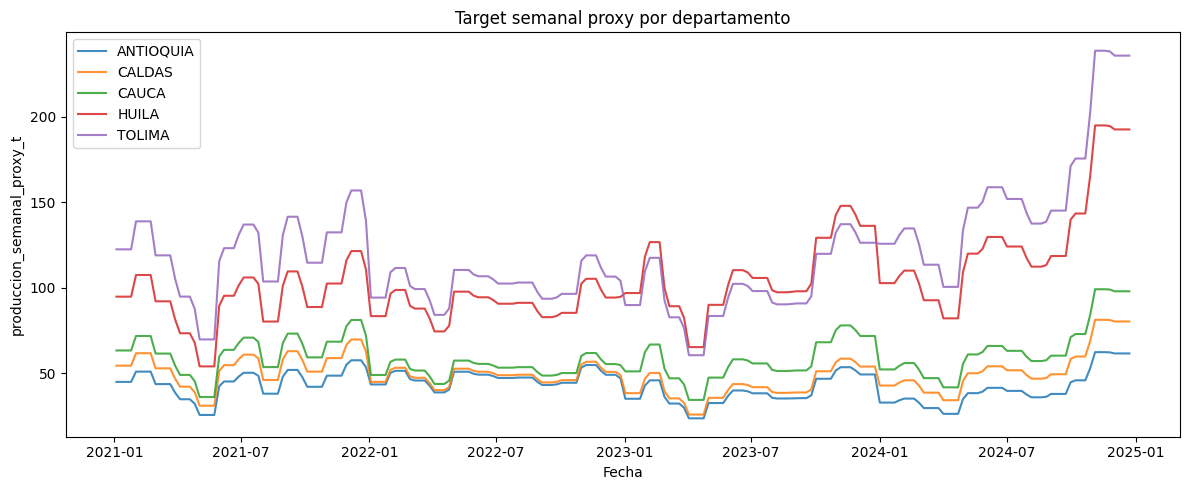

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
for dept, g in panel.groupby(DEPT_COL_PANEL):
    ax.plot(g[DATE_COL_PANEL], g[TARGET], label=str(dept), alpha=0.85)
ax.set_title("Target semanal proxy por departamento")
ax.set_xlabel("Fecha")
ax.set_ylabel(TARGET)
ax.legend()
plt.tight_layout()
plt.show()

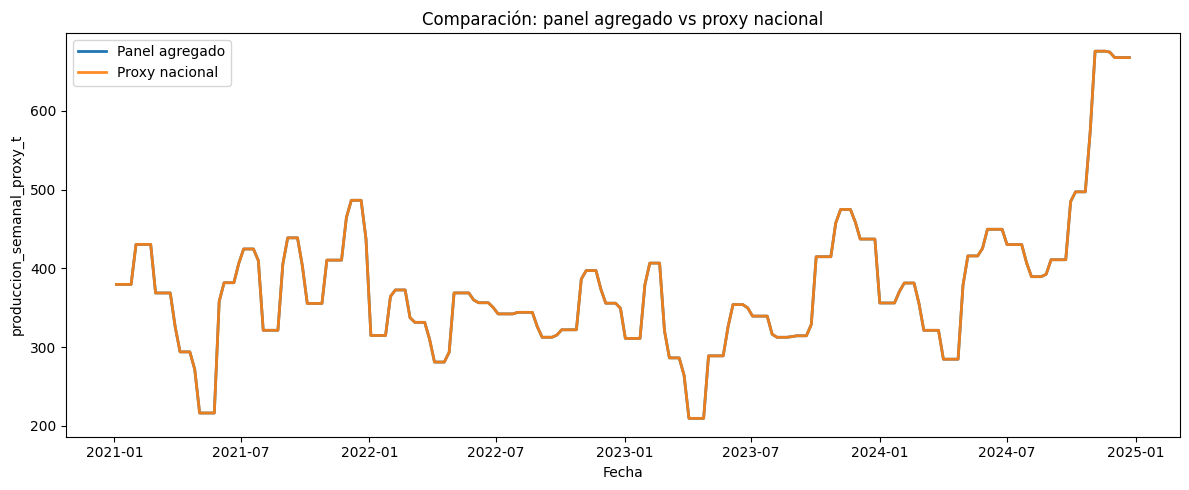

In [33]:
agg_panel = panel.groupby(DATE_COL_PANEL)[TARGET].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(agg_panel[DATE_COL_PANEL], agg_panel[TARGET], label="Panel agregado", linewidth=2)
if TARGET in proxy.columns:
    ax.plot(proxy[DATE_COL_PROXY], proxy[TARGET], label="Proxy nacional", linewidth=2, alpha=0.9)
ax.set_title("Comparación: panel agregado vs proxy nacional")
ax.set_xlabel("Fecha")
ax.set_ylabel(TARGET)
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
candidate_num = [
    "PRECTOTCORR", "IMERG_PRECTOT", "T2M", "T2M_MAX", "T2M_MIN",
    "RH2M", "QV2M", "GWETTOP", "GWETROOT", "ALLSKY_SFC_SW_DWN",
    "WS2M", "lluvia_acum_4s", "lluvia_acum_8s", "anomalia_lluvia_semana_iso",
    "t2m_max_ma_4s", "gwetroot_ma_4s", "gwettop_ma_4s",
    "precio_interno_cop_carga", "trm_viernes_cop_usd", "exportaciones_mensual_miles_sacos"
]
candidate_num = [c for c in candidate_num if c in panel.columns]

if candidate_num:
    corr_df = panel[[TARGET] + candidate_num].corr(numeric_only=True)[[TARGET]].sort_values(TARGET, ascending=False)
    display(corr_df.head(15))
    display(corr_df.tail(15))

,produccion_semanal_proxy_t
produccion_semanal_proxy_t,1.000000
WS2M,0.504315
exportaciones_mensual_miles_sacos,0.309919
precio_interno_cop_carga,0.133464
T2M,0.025657
t2m_max_ma_4s,0.019398
T2M_MAX,0.011568
anomalia_lluvia_semana_iso,0.011407
trm_viernes_cop_usd,0.011079
T2M_MIN,-0.018486


,produccion_semanal_proxy_t
T2M_MAX,0.011568
anomalia_lluvia_semana_iso,0.011407
trm_viernes_cop_usd,0.011079
T2M_MIN,-0.018486
PRECTOTCORR,-0.060809
lluvia_acum_4s,-0.083749
QV2M,-0.100477
lluvia_acum_8s,-0.100730
RH2M,-0.217290
ALLSKY_SFC_SW_DWN,-0.233385


## 5. Ingeniería temporal básica

In [35]:
def add_time_features(df, date_col):
    out = df.copy()
    out["year"] = out[date_col].dt.year
    out["month"] = out[date_col].dt.month
    out["quarter"] = out[date_col].dt.quarter
    out["weekofyear"] = out[date_col].dt.isocalendar().week.astype(int)
    out["sin_week"] = np.sin(2*np.pi*out["weekofyear"]/52)
    out["cos_week"] = np.cos(2*np.pi*out["weekofyear"]/52)
    return out

panel = add_time_features(panel, DATE_COL_PANEL)
proxy = add_time_features(proxy, DATE_COL_PROXY)

panel.head()

,fecha_semana_inicio,fecha_semana_fin,anio_semana_fin,anio_referencia_y,mes_referencia_y,semana_iso,dias_productivos_periodo_2021_2024,departamento,nivel,produccion_semanal_proxy_t,...,valor_cosecha_anual_millones,valor_cosecha_semanal_proxy_millones,fuente_y_semanal,tipo_target,year,month,quarter,weekofyear,sin_week,cos_week
0,2021-01-04,2021-01-10,2021,2021,1,1,7,ANTIOQUIA,PANEL_DEPARTAMENTAL,44.908023,...,1.076853e+07,208997.658164,mensualizacion_estacionalidad_nacional_y_seman...,proxy_operacional_no_observada,2021,1,1,1,0.120537,0.992709
1,2021-01-11,2021-01-17,2021,2021,1,2,7,ANTIOQUIA,PANEL_DEPARTAMENTAL,44.908023,...,1.076853e+07,208997.658164,mensualizacion_estacionalidad_nacional_y_seman...,proxy_operacional_no_observada,2021,1,1,2,0.239316,0.970942
2,2021-01-18,2021-01-24,2021,2021,1,3,7,ANTIOQUIA,PANEL_DEPARTAMENTAL,44.908023,...,1.076853e+07,208997.658164,mensualizacion_estacionalidad_nacional_y_seman...,proxy_operacional_no_observada,2021,1,1,3,0.354605,0.935016
3,2021-01-25,2021-01-31,2021,2021,1,4,7,ANTIOQUIA,PANEL_DEPARTAMENTAL,44.908023,...,1.076853e+07,208997.658164,mensualizacion_estacionalidad_nacional_y_seman...,proxy_operacional_no_observada,2021,1,1,4,0.464723,0.885456
4,2021-02-01,2021-02-07,2021,2021,2,5,7,ANTIOQUIA,PANEL_DEPARTAMENTAL,50.915443,...,1.076853e+07,236955.617656,mensualizacion_estacionalidad_nacional_y_seman...,proxy_operacional_no_observada,2021,2,1,5,0.568065,0.822984


## 6. Definir grupos de variables

In [36]:
def keep_existing(df, cols):
    return [c for c in cols if c in df.columns]

CLIMA_CRUDO = [
    "PRECTOTCORR", "IMERG_PRECTOT",
    "T2M", "T2M_MAX", "T2M_MIN",
    "RH2M", "QV2M", "GWETTOP", "GWETROOT",
    "ALLSKY_SFC_SW_DWN", "WS2M"
]

CLIMA_DERIVADO = [
    "lluvia_acum_4s", "lluvia_acum_8s",
    "anomalia_lluvia_semana_iso",
    "t2m_max_ma_4s", "gwetroot_ma_4s", "gwettop_ma_4s",
    "dummy_exceso_lluvia_p75", "dummy_estres_hidrico_p25",
    "dummy_temp_max_alta_p75",
    "dummy_indice_climatico_bajo_p25", "dummy_indice_climatico_alto_p75"
]

INDICE_AGREGADO = [
    "indice_climatico_base_x",
    "indice_climatico_ajustado_x"
]

ECONOMICAS = [
    "precio_interno_cop_carga",
    "precio_interno_cop_carga_lag_1s",
    "precio_interno_cop_carga_lag_4s",
    "precio_interno_cop_carga_ma_4s",
    "precio_interno_cop_carga_var_4s",
    "precio_externo_exdock_cent_usd_lb",
    "precio_externo_exdock_cent_usd_lb_lag_1s",
    "precio_externo_exdock_cent_usd_lb_lag_4s",
    "precio_externo_exdock_cent_usd_lb_ma_4s",
    "precio_externo_exdock_cent_usd_lb_var_4s",
    "exportaciones_mensual_miles_sacos",
    "exportaciones_mensual_miles_sacos_lag_1s",
    "exportaciones_mensual_miles_sacos_lag_4s",
    "exportaciones_mensual_miles_sacos_ma_4s",
    "exportaciones_mensual_miles_sacos_var_4s",
    "trm_viernes_cop_usd",
    "trm_promedio_semana_cop_usd",
    "trm_viernes_cop_usd_lag_1s",
    "trm_viernes_cop_usd_lag_4s",
    "trm_viernes_cop_usd_ma_4s",
    "trm_viernes_cop_usd_var_4s",
    "dummy_trm_lag4_alta_p75",
    "dummy_devaluacion_4s_p75",
    "dummy_precio_interno_alto_p75",
    "dummy_precio_externo_alto_p75",
    "dummy_exportaciones_altas_p75",
]

BASELINE_TEMPORAL = [DEPT_COL_PANEL, "year", "month", "quarter", "weekofyear", "sin_week", "cos_week"]

CLIMA_CRUDO = keep_existing(panel, CLIMA_CRUDO)
CLIMA_DERIVADO = keep_existing(panel, CLIMA_DERIVADO)
INDICE_AGREGADO = keep_existing(panel, INDICE_AGREGADO)
ECONOMICAS = keep_existing(panel, ECONOMICAS)
BASELINE_TEMPORAL = keep_existing(panel, BASELINE_TEMPORAL)
STRUCTURAL = keep_existing(panel, STRUCTURAL_ANNUAL_VARS)

print("CLIMA_CRUDO:", CLIMA_CRUDO)
print("CLIMA_DERIVADO:", CLIMA_DERIVADO)
print("INDICE_AGREGADO:", INDICE_AGREGADO)
print("ECONOMICAS:", ECONOMICAS)
print("BASELINE_TEMPORAL:", BASELINE_TEMPORAL)
print("STRUCTURAL:", STRUCTURAL)

CLIMA_CRUDO: ['PRECTOTCORR', 'IMERG_PRECTOT', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'QV2M', 'GWETTOP', 'GWETROOT', 'ALLSKY_SFC_SW_DWN', 'WS2M']
CLIMA_DERIVADO: ['lluvia_acum_4s', 'lluvia_acum_8s', 'anomalia_lluvia_semana_iso', 't2m_max_ma_4s', 'gwetroot_ma_4s', 'gwettop_ma_4s', 'dummy_exceso_lluvia_p75', 'dummy_estres_hidrico_p25', 'dummy_temp_max_alta_p75', 'dummy_indice_climatico_bajo_p25', 'dummy_indice_climatico_alto_p75']
INDICE_AGREGADO: ['indice_climatico_base_x', 'indice_climatico_ajustado_x']
ECONOMICAS: ['precio_interno_cop_carga', 'precio_interno_cop_carga_lag_1s', 'precio_interno_cop_carga_lag_4s', 'precio_interno_cop_carga_ma_4s', 'precio_interno_cop_carga_var_4s', 'precio_externo_exdock_cent_usd_lb', 'precio_externo_exdock_cent_usd_lb_lag_1s', 'precio_externo_exdock_cent_usd_lb_lag_4s', 'precio_externo_exdock_cent_usd_lb_ma_4s', 'precio_externo_exdock_cent_usd_lb_var_4s', 'exportaciones_mensual_miles_sacos', 'exportaciones_mensual_miles_sacos_lag_1s', 'exportaciones_mensua

## 7. Construir dataset limpio para modelado

In [37]:
drop_cols = set(LEAKAGE_COLS + EXTRA_POTENTIAL_LEAKAGE)
if not USE_STRUCTURAL_VARS:
    drop_cols = drop_cols.union(STRUCTURAL_ANNUAL_VARS)

drop_cols = sorted([c for c in drop_cols if c in panel.columns])

panel_model = panel.drop(columns=drop_cols, errors="ignore").copy()

print("Columnas eliminadas por leakage / construcción / decisión conservadora:")
print(drop_cols)
print("\nShape panel_model:", panel_model.shape)

Columnas eliminadas por leakage / construcción / decisión conservadora:
['area_cosechada_departamental_ha', 'fuente_y_semanal', 'peso_mensual_prod_nacional', 'produccion_anual_departamental_t', 'produccion_mensual_proxy_t', 'produccion_nacional_mensual_oficial_miles_sacos', 'rendimiento_departamental_t_ha', 'score_humedad', 'score_precipitacion', 'score_radiacion', 'score_temperatura', 'tipo_target', 'valor_cosecha_anual_millones', 'valor_cosecha_semanal_proxy_millones']

Shape panel_model: (1040, 66)


## 8. Split temporal

In [38]:
panel_model["year_split"] = panel_model[DATE_COL_PANEL].dt.year

train_df = panel_model[panel_model["year_split"].isin([2021, 2022])].copy()
val_df   = panel_model[panel_model["year_split"] == 2023].copy()
test_df  = panel_model[panel_model["year_split"] == 2024].copy()

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (520, 67)
val: (260, 67)
test: (260, 67)


## 9. Funciones auxiliares

In [39]:
def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols)
        ],
        remainder="drop"
    )
    return preprocessor, numeric_cols, categorical_cols


def metrics_reg(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    den = np.where(np.abs(y_true) < 1e-9, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / den)) * 100

    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_pct": mape,
        "R2": r2,
        "Corr": corr
    }


def run_experiment(train_df, val_df, test_df, features, model_name, model):
    keep = [c for c in features if c in train_df.columns]
    X_train = train_df[keep].copy()
    y_train = train_df[TARGET].copy()

    X_val = val_df[keep].copy()
    y_val = val_df[TARGET].copy()

    X_test = test_df[keep].copy()
    y_test = test_df[TARGET].copy()

    preprocessor, _, _ = build_preprocessor(X_train)
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred_val = pipe.predict(X_val)
    pred_test = pipe.predict(X_test)

    m_val = metrics_reg(y_val, pred_val)
    m_test = metrics_reg(y_test, pred_test)

    return {
        "features_n": len(keep),
        "features_used": keep,
        "model_type": model_name,
        "val_RMSE": m_val["RMSE"],
        "val_MAE": m_val["MAE"],
        "val_MAPE_pct": m_val["MAPE_pct"],
        "val_R2": m_val["R2"],
        "val_Corr": m_val["Corr"],
        "test_RMSE": m_test["RMSE"],
        "test_MAE": m_test["MAE"],
        "test_MAPE_pct": m_test["MAPE_pct"],
        "test_R2": m_test["R2"],
        "test_Corr": m_test["Corr"],
        "pipeline": pipe
    }

## 10. Definir versiones experimentales

In [40]:
EXPERIMENTS = {
    "V0_dummy_mean": {
        "features": BASELINE_TEMPORAL,
        "model_name": "dummy",
        "model": DummyRegressor(strategy="mean")
    },
    "V1_baseline_ridge": {
        "features": BASELINE_TEMPORAL,
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    },
    "V2_clima_crudo_ridge": {
        "features": BASELINE_TEMPORAL + CLIMA_CRUDO,
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    },
    "V3_clima_derivado_ridge": {
        "features": BASELINE_TEMPORAL + CLIMA_DERIVADO,
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    },
    "V4_indice_base_ridge": {
        "features": BASELINE_TEMPORAL + INDICE_AGREGADO[:1],
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    },
    "V5_clima_crudo_rf": {
        "features": BASELINE_TEMPORAL + CLIMA_CRUDO,
        "model_name": "rf",
        "model": RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    },
    "V6_clima_derivado_rf": {
        "features": BASELINE_TEMPORAL + CLIMA_DERIVADO,
        "model_name": "rf",
        "model": RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    },
    "V7_clima_mas_economicas_rf": {
        "features": BASELINE_TEMPORAL + CLIMA_DERIVADO + ECONOMICAS,
        "model_name": "rf",
        "model": RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    }
}

if XGBOOST_AVAILABLE:
    EXPERIMENTS["V8_clima_derivado_xgb"] = {
        "features": BASELINE_TEMPORAL + CLIMA_DERIVADO,
        "model_name": "xgb",
        "model": XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42
        )
    }

list(EXPERIMENTS.keys())

['V0_dummy_mean',
 'V1_baseline_ridge',
 'V2_clima_crudo_ridge',
 'V3_clima_derivado_ridge',
 'V4_indice_base_ridge',
 'V5_clima_crudo_rf',
 'V6_clima_derivado_rf',
 'V7_clima_mas_economicas_rf',
 'V8_clima_derivado_xgb']

## 11. Correr experimentos sobre la base panel

In [41]:
results = []

for name, spec in EXPERIMENTS.items():
    print(f"Corriendo {name} ...")
    out = run_experiment(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        features=spec["features"],
        model_name=spec["model_name"],
        model=spec["model"]
    )
    out["experiment"] = name
    results.append(out)

results_df = pd.DataFrame(results).drop(columns=["pipeline", "features_used"], errors="ignore")
results_df = results_df.sort_values(["val_RMSE", "test_RMSE"])
display(results_df)

Corriendo V0_dummy_mean ...
Corriendo V1_baseline_ridge ...
Corriendo V2_clima_crudo_ridge ...
Corriendo V3_clima_derivado_ridge ...
Corriendo V4_indice_base_ridge ...
Corriendo V5_clima_crudo_rf ...
Corriendo V6_clima_derivado_rf ...
Corriendo V7_clima_mas_economicas_rf ...
Corriendo V8_clima_derivado_xgb ...


,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr,experiment
7,44,rf,15.321890,11.567698,18.244034,0.780861,8.993775e-01,30.599104,19.523131,19.084154,0.648776,9.401887e-01,V7_clima_mas_economicas_rf
5,18,rf,15.397304,11.707438,18.710357,0.778699,8.927368e-01,36.105240,22.345469,20.564865,0.511001,8.774270e-01,V5_clima_crudo_rf
8,18,xgb,15.952924,11.738012,18.239108,0.762439,8.859107e-01,36.555220,23.281675,21.873696,0.498737,8.881088e-01,V8_clima_derivado_xgb
6,18,rf,16.548826,12.727973,20.205473,0.744360,8.680843e-01,36.069071,22.459488,21.560448,0.511981,8.626105e-01,V6_clima_derivado_rf
4,8,ridge,17.214336,12.380985,16.373496,0.723385,8.806039e-01,43.575609,31.664100,31.134631,0.287715,9.080489e-01,V4_indice_base_ridge
1,7,ridge,17.537376,12.641844,16.668015,0.712906,8.781665e-01,44.222584,32.539383,32.406730,0.266407,9.102976e-01,V1_baseline_ridge
2,18,ridge,18.392441,13.374363,17.962554,0.684228,8.729403e-01,46.651656,35.911898,37.966539,0.183603,9.112922e-01,V2_clima_crudo_ridge
3,18,ridge,18.728962,13.855422,18.345589,0.672567,8.800123e-01,47.583890,36.347945,37.900511,0.150649,9.035232e-01,V3_clima_derivado_ridge
0,7,dummy,32.827842,28.887284,52.267359,-0.005957,-4.558867e-16,54.101825,41.430388,50.708064,-0.097971,1.016253e-16,V0_dummy_mean


## 12. Seleccionar mejor modelo y revisar predicción vs real

Mejor experimento (según val_RMSE): V7_clima_mas_economicas_rf
Features usadas: ['departamento', 'year', 'month', 'quarter', 'weekofyear', 'sin_week', 'cos_week', 'lluvia_acum_4s', 'lluvia_acum_8s', 'anomalia_lluvia_semana_iso', 't2m_max_ma_4s', 'gwetroot_ma_4s', 'gwettop_ma_4s', 'dummy_exceso_lluvia_p75', 'dummy_estres_hidrico_p25', 'dummy_temp_max_alta_p75', 'dummy_indice_climatico_bajo_p25', 'dummy_indice_climatico_alto_p75', 'precio_interno_cop_carga', 'precio_interno_cop_carga_lag_1s', 'precio_interno_cop_carga_lag_4s', 'precio_interno_cop_carga_ma_4s', 'precio_interno_cop_carga_var_4s', 'precio_externo_exdock_cent_usd_lb', 'precio_externo_exdock_cent_usd_lb_lag_1s', 'precio_externo_exdock_cent_usd_lb_lag_4s', 'precio_externo_exdock_cent_usd_lb_ma_4s', 'precio_externo_exdock_cent_usd_lb_var_4s', 'exportaciones_mensual_miles_sacos', 'exportaciones_mensual_miles_sacos_lag_1s', 'exportaciones_mensual_miles_sacos_lag_4s', 'exportaciones_mensual_miles_sacos_ma_4s', 'exportaciones_mensu

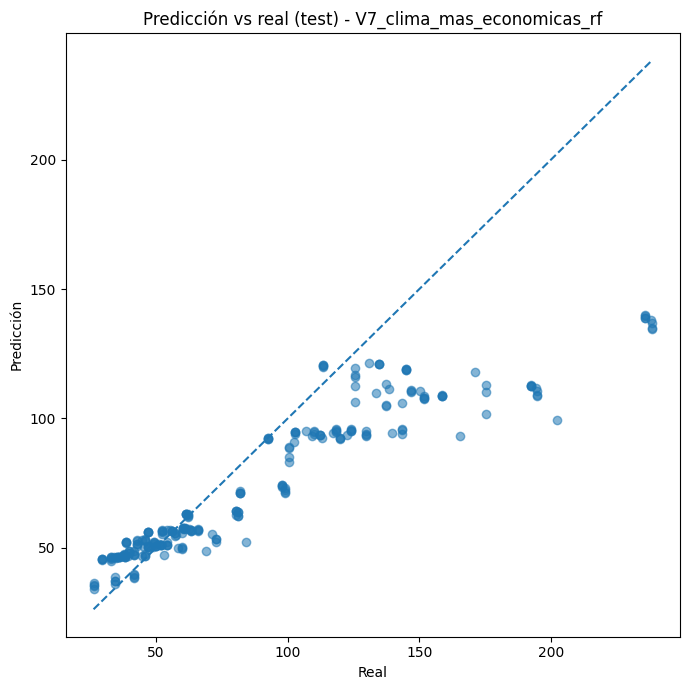

In [43]:
best_name = results_df.iloc[0]["experiment"]
best_result = [r for r in results if r["experiment"] == best_name][0]
best_pipe = best_result["pipeline"]
best_features = best_result["features_used"]

print("Mejor experimento (según val_RMSE):", best_name)
print("Features usadas:", best_features)

X_test_best = test_df[best_features].copy()
y_test_best = test_df[TARGET].copy()
pred_test_best = best_pipe.predict(X_test_best)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test_best, pred_test_best, alpha=0.55)
lims = [min(y_test_best.min(), pred_test_best.min()), max(y_test_best.max(), pred_test_best.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_title(f"Predicción vs real (test) - {best_name}")
ax.set_xlabel("Real")
ax.set_ylabel("Predicción")
plt.tight_layout()
plt.show()

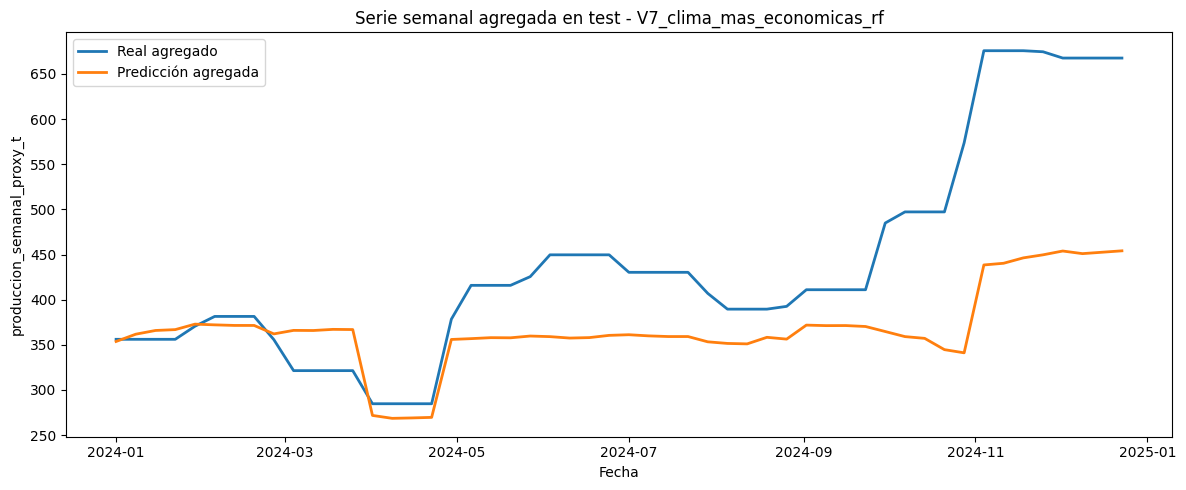

In [44]:
test_plot = test_df[[DATE_COL_PANEL, TARGET]].copy()
test_plot["pred"] = pred_test_best
series = test_plot.groupby(DATE_COL_PANEL)[[TARGET, "pred"]].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(series[DATE_COL_PANEL], series[TARGET], label="Real agregado", linewidth=2)
ax.plot(series[DATE_COL_PANEL], series["pred"], label="Predicción agregada", linewidth=2)
ax.set_title(f"Serie semanal agregada en test - {best_name}")
ax.set_xlabel("Fecha")
ax.set_ylabel(TARGET)
ax.legend()
plt.tight_layout()
plt.show()

## 13. Benchmark secundario sobre la proxy nacional

In [45]:
if TARGET in proxy.columns:
    proxy_model = proxy.copy()
    proxy_drop = [c for c in (LEAKAGE_COLS + EXTRA_POTENTIAL_LEAKAGE) if c in proxy_model.columns]
    proxy_model = proxy_model.drop(columns=proxy_drop, errors="ignore")
    proxy_model["year_split"] = proxy_model[DATE_COL_PROXY].dt.year

    train_p = proxy_model[proxy_model["year_split"].isin([2021, 2022])].copy()
    val_p   = proxy_model[proxy_model["year_split"] == 2023].copy()
    test_p  = proxy_model[proxy_model["year_split"] == 2024].copy()

    proxy_features = [c for c in ["year", "month", "quarter", "weekofyear", "sin_week", "cos_week"] if c in proxy_model.columns]
    proxy_features += [c for c in CLIMA_DERIVADO if c in proxy_model.columns]

    proxy_result = run_experiment(
        train_df=train_p,
        val_df=val_p,
        test_df=test_p,
        features=proxy_features,
        model_name="ridge",
        model=RidgeCV(alphas=np.logspace(-3, 3, 20))
    )

    proxy_summary = {k: v for k, v in proxy_result.items() if k not in ["pipeline", "features_used"]}
    display(pd.DataFrame([proxy_summary]))

,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr
0,17,ridge,130.69888,112.453874,30.199971,-2.428942,0.228724,302.359102,283.939216,63.441257,-5.961572,0.480254


,feature,importance
47,cat__departamento_TOLIMA,0.509248
46,cat__departamento_HUILA,0.309048
27,num__exportaciones_mensual_miles_sacos,0.077056
31,num__exportaciones_mensual_miles_sacos_var_4s,0.030307
45,cat__departamento_CAUCA,0.011667
7,num__lluvia_acum_8s,0.008712
9,num__t2m_max_ma_4s,0.005914
22,num__precio_externo_exdock_cent_usd_lb,0.005511
11,num__gwettop_ma_4s,0.003653
42,num__dummy_exportaciones_altas_p75,0.003533


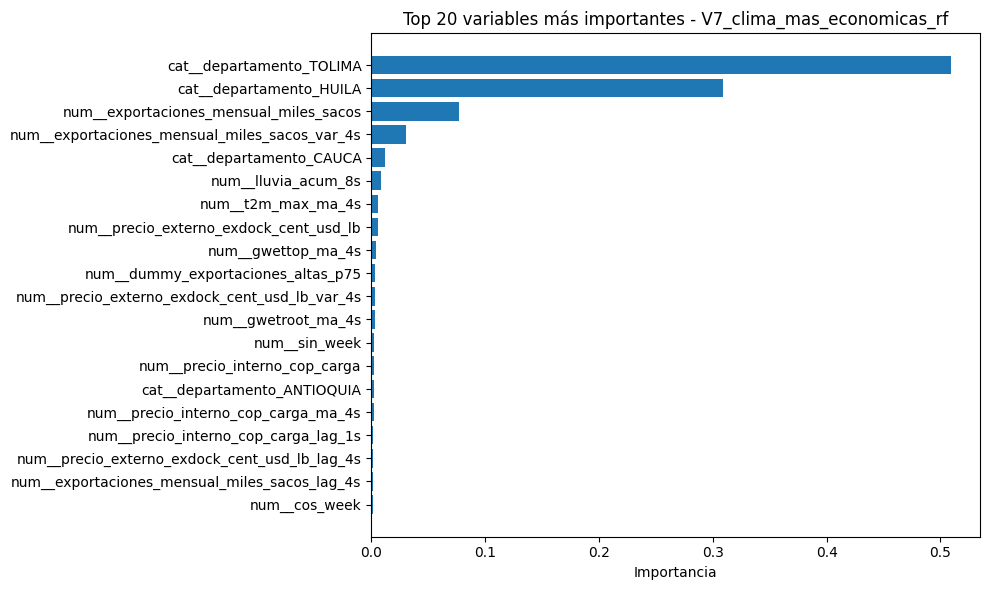

In [46]:
# Importancia de variables del mejor modelo
model_step = best_pipe.named_steps["model"]
prep_step = best_pipe.named_steps["prep"]

feature_names = prep_step.get_feature_names_out()
importances = model_step.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feat_imp.head(20))

plt.figure(figsize=(10, 6))
topn = 20
plot_df = feat_imp.head(topn).sort_values("importance")
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title(f"Top {topn} variables más importantes - {best_name}")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [47]:
# Predicción en test por departamento
test_eval = test_df[[DATE_COL_PANEL, DEPT_COL_PANEL, TARGET]].copy()
test_eval["pred"] = pred_test_best

def metrics_reg_simple(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    den = np.where(np.abs(y_true) < 1e-9, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / den)) * 100
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return pd.Series({
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_pct": mape,
        "R2": r2,
        "Corr": corr
    })

dept_metrics = (
    test_eval.groupby(DEPT_COL_PANEL)
    .apply(lambda g: metrics_reg_simple(g[TARGET], g["pred"]))
    .reset_index()
    .sort_values("RMSE")
)

display(dept_metrics)

,departamento,RMSE,MAE,MAPE_pct,R2,Corr
0,ANTIOQUIA,9.325262,8.152784,23.613917,0.220497,0.925501
1,CALDAS,9.488672,7.337729,13.479407,0.525108,0.811204
2,CAUCA,12.945280,9.272419,12.623386,0.406086,0.835983
3,HUILA,40.636722,31.567411,21.933941,-0.513517,0.850593
4,TOLIMA,51.822842,41.285312,23.770120,-0.642526,0.695093


In [48]:
compare_v6_v7 = results_df[results_df["experiment"].isin(["V6_clima_derivado_rf", "V7_clima_mas_economicas_rf"])].copy()
display(compare_v6_v7)

,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr,experiment
7,44,rf,15.321890,11.567698,18.244034,0.780861,0.899377,30.599104,19.523131,19.084154,0.648776,0.940189,V7_clima_mas_economicas_rf
6,18,rf,16.548826,12.727973,20.205473,0.744360,0.868084,36.069071,22.459488,21.560448,0.511981,0.862610,V6_clima_derivado_rf


In [49]:
# =========================
# A. V7 sin departamento
# =========================

features_v7 = EXPERIMENTS["V7_clima_mas_economicas_rf"]["features"]
features_v7_no_dept = [c for c in features_v7 if c != DEPT_COL_PANEL]

print("Features V7 originales:", len(features_v7))
print("Features V7 sin departamento:", len(features_v7_no_dept))
print(features_v7_no_dept)

v7_no_dept_result = run_experiment(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    features=features_v7_no_dept,
    model_name="rf",
    model=RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
)

v7_no_dept_summary = {k: v for k, v in v7_no_dept_result.items() if k not in ["pipeline", "features_used"]}
display(pd.DataFrame([v7_no_dept_summary]))

Features V7 originales: 44
Features V7 sin departamento: 43
['year', 'month', 'quarter', 'weekofyear', 'sin_week', 'cos_week', 'lluvia_acum_4s', 'lluvia_acum_8s', 'anomalia_lluvia_semana_iso', 't2m_max_ma_4s', 'gwetroot_ma_4s', 'gwettop_ma_4s', 'dummy_exceso_lluvia_p75', 'dummy_estres_hidrico_p25', 'dummy_temp_max_alta_p75', 'dummy_indice_climatico_bajo_p25', 'dummy_indice_climatico_alto_p75', 'precio_interno_cop_carga', 'precio_interno_cop_carga_lag_1s', 'precio_interno_cop_carga_lag_4s', 'precio_interno_cop_carga_ma_4s', 'precio_interno_cop_carga_var_4s', 'precio_externo_exdock_cent_usd_lb', 'precio_externo_exdock_cent_usd_lb_lag_1s', 'precio_externo_exdock_cent_usd_lb_lag_4s', 'precio_externo_exdock_cent_usd_lb_ma_4s', 'precio_externo_exdock_cent_usd_lb_var_4s', 'exportaciones_mensual_miles_sacos', 'exportaciones_mensual_miles_sacos_lag_1s', 'exportaciones_mensual_miles_sacos_lag_4s', 'exportaciones_mensual_miles_sacos_ma_4s', 'exportaciones_mensual_miles_sacos_var_4s', 'trm_viernes

,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr
0,43,rf,28.144742,21.264654,37.49049,0.260583,0.525668,45.640426,33.627849,40.441652,0.218612,0.555067


In [50]:
# =========================
# B. V7 por departamento
# =========================

features_v7_no_dept = [c for c in EXPERIMENTS["V7_clima_mas_economicas_rf"]["features"] if c != DEPT_COL_PANEL]

dept_results = []

for dept in sorted(panel_model[DEPT_COL_PANEL].dropna().unique()):
    df_dept = panel_model[panel_model[DEPT_COL_PANEL] == dept].copy()

    train_d = df_dept[df_dept["year_split"].isin([2021, 2022])].copy()
    val_d   = df_dept[df_dept["year_split"] == 2023].copy()
    test_d  = df_dept[df_dept["year_split"] == 2024].copy()

    # Saltar si no hay suficientes datos
    if len(train_d) < 20 or len(val_d) < 5 or len(test_d) < 5:
        print(f"Saltando {dept}: pocos datos")
        continue

    out = run_experiment(
        train_df=train_d,
        val_df=val_d,
        test_df=test_d,
        features=features_v7_no_dept,
        model_name="rf",
        model=RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    )

    dept_results.append({
        "departamento": dept,
        "features_n": out["features_n"],
        "val_RMSE": out["val_RMSE"],
        "val_MAE": out["val_MAE"],
        "val_MAPE_pct": out["val_MAPE_pct"],
        "val_R2": out["val_R2"],
        "val_Corr": out["val_Corr"],
        "test_RMSE": out["test_RMSE"],
        "test_MAE": out["test_MAE"],
        "test_MAPE_pct": out["test_MAPE_pct"],
        "test_R2": out["test_R2"],
        "test_Corr": out["test_Corr"],
    })

dept_results_df = pd.DataFrame(dept_results).sort_values("test_RMSE")
display(dept_results_df)

,departamento,features_n,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr
1,CALDAS,43,8.793738,7.504334,20.056200,-0.022456,0.650369,9.981693,7.960776,15.037641,0.474476,0.764809
0,ANTIOQUIA,43,9.355342,7.904733,23.781514,-0.383801,0.735763,10.942030,10.338334,28.265611,-0.073227,0.770952
2,CAUCA,43,8.987483,7.453381,12.946284,0.398006,0.755693,13.023677,9.334461,12.727271,0.398871,0.833465
3,HUILA,43,25.033525,19.516838,16.364690,-0.298128,0.710671,40.699732,31.339744,21.653786,-0.518214,0.851360
4,TOLIMA,43,15.577864,13.601778,14.768201,0.415562,0.692131,51.693710,41.476151,23.938850,-0.634350,0.725117


,family,importance
3,territorial,0.832144
1,economica,0.138520
0,climatica,0.023337
2,temporal,0.005999


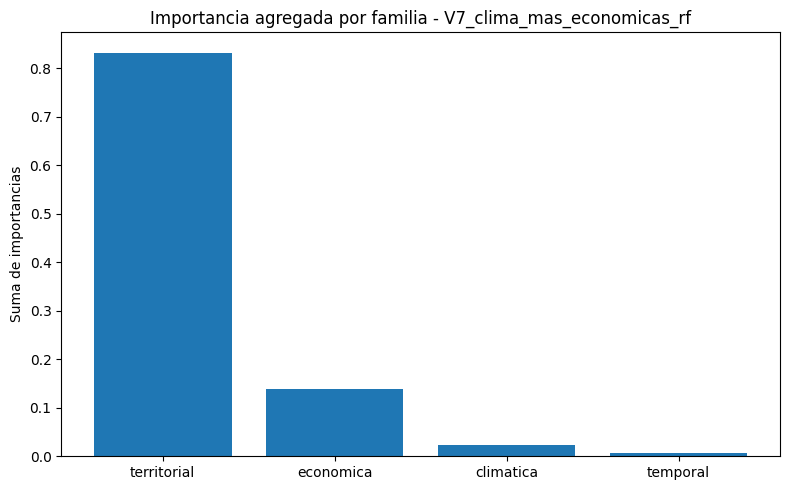

In [51]:
# =========================
# C. Agrupar importancias por familia
# =========================

def classify_feature_family(feature_name):
    f = feature_name.lower()

    # Territoriales
    if "departamento" in f:
        return "territorial"

    # Temporales
    if any(x in f for x in ["year", "month", "quarter", "weekofyear", "sin_week", "cos_week"]):
        return "temporal"

    # Económicas / mercado
    if any(x in f for x in [
        "precio_", "trm", "exportaciones", "devaluacion"
    ]):
        return "economica"

    # Climáticas / índice
    if any(x in f for x in [
        "prectotcorr", "imerg_prectot", "t2m", "rh2m", "qv2m", "gwettop", "gwetroot",
        "allsky", "ws2m", "lluvia", "humedad", "indice_climatico", "estres_hidrico",
        "temp_max", "exceso_lluvia"
    ]):
        return "climatica"

    return "otra"

feat_imp_family = feat_imp.copy()
feat_imp_family["family"] = feat_imp_family["feature"].apply(classify_feature_family)

family_summary = (
    feat_imp_family.groupby("family", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(family_summary)

plt.figure(figsize=(8, 5))
plt.bar(family_summary["family"], family_summary["importance"])
plt.title(f"Importancia agregada por familia - {best_name}")
plt.ylabel("Suma de importancias")
plt.tight_layout()
plt.show()

In [1]:
# =========================
# MONTHLY + ANNUAL
# Lectura del Excel consolidado
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

PATH_XLSX = "/content/bases_panel_cafe_mensual_anual.xlsx"

xlsx = pd.ExcelFile(PATH_XLSX)
print("Hojas disponibles:", xlsx.sheet_names)

monthly = pd.read_excel(PATH_XLSX, sheet_name="monthly_from_weekly")
annual  = pd.read_excel(PATH_XLSX, sheet_name="annual_from_weekly")

monthly.columns = [c.strip() for c in monthly.columns]
annual.columns = [c.strip() for c in annual.columns]

print("Shape monthly:", monthly.shape)
print("Shape annual:", annual.shape)

display(monthly.head())
display(annual.head())

Hojas disponibles: ['weekly_source', 'monthly_from_weekly', 'annual_from_weekly', 'checks']
Shape monthly: (240, 74)
Shape annual: (20, 73)


,departamento,anio_referencia_y,mes_referencia_y,produccion_mensual_desde_semana_t,produccion_mensual_proxy_t,produccion_anual_departamental_t,area_cosechada_departamental_ha,rendimiento_departamental_t_ha,peso_mensual_prod_nacional,produccion_nacional_mensual_oficial_miles_sacos,...,exportaciones_mensual_miles_sacos_var_4s_mean,trm_viernes_cop_usd_mean,trm_promedio_semana_cop_usd_mean,trm_viernes_cop_usd_lag_1s_mean,trm_viernes_cop_usd_lag_4s_mean,trm_viernes_cop_usd_ma_4s_mean,trm_viernes_cop_usd_var_4s_mean,nivel,dias_productivos_periodo_2021_2024,diff_target_mensual
0,ANTIOQUIA,2021,1,179.632091,198.878387,2313.87,1752.93,1.229704,0.085951,1081.0,...,0.000000,3507.4050,3497.6225,3475.6650,3432.5000,3491.5350,0.036988,PANEL_DEPARTAMENTAL,7,-19.246295
1,ANTIOQUIA,2021,2,203.661771,203.661771,2313.87,1752.93,1.394204,0.088018,1107.0,...,0.188097,3559.6800,3554.5050,3543.4475,3507.4050,3540.6850,0.014906,PANEL_DEPARTAMENTAL,7,0.000000
2,ANTIOQUIA,2021,3,174.480755,193.175121,2313.87,1752.93,1.194440,0.083486,1050.0,...,-0.114344,3608.5625,3603.1300,3598.3075,3559.6800,3597.4000,0.013765,PANEL_DEPARTAMENTAL,7,-18.694367
3,ANTIOQUIA,2021,4,175.026749,149.020808,2313.87,1752.93,1.198177,0.064403,810.0,...,-0.065943,3660.9260,3660.3360,3645.9800,3622.5740,3640.0300,0.010641,PANEL_DEPARTAMENTAL,7,26.005941
4,ANTIOQUIA,2021,5,102.362043,113.329404,2313.87,1752.93,0.700738,0.048978,616.0,...,-0.666675,3725.4100,3736.0750,3731.6250,3656.5025,3712.3525,0.019028,PANEL_DEPARTAMENTAL,7,-10.967362


,departamento,anio_referencia_y,produccion_anual_desde_semana_t,produccion_mensual_proxy_t,produccion_anual_departamental_t,area_cosechada_departamental_ha,rendimiento_departamental_t_ha,peso_mensual_prod_nacional,produccion_nacional_mensual_oficial_miles_sacos,valor_cosecha_anual_millones,...,exportaciones_mensual_miles_sacos_var_4s_mean,trm_viernes_cop_usd_mean,trm_promedio_semana_cop_usd_mean,trm_viernes_cop_usd_lag_1s_mean,trm_viernes_cop_usd_lag_4s_mean,trm_viernes_cop_usd_ma_4s_mean,trm_viernes_cop_usd_var_4s_mean,nivel,dias_productivos_periodo_2021_2024,diff_target_anual
0,ANTIOQUIA,2021,2313.87,198.878387,2313.87,1752.93,1.32,0.085951,1081,1.076853e+07,...,0.101066,3749.625192,3746.956154,3739.074038,3725.513061,3745.000200,0.011042,PANEL_DEPARTAMENTAL,7,-6.843999
1,ANTIOQUIA,2022,2454.68,192.235590,2454.68,1789.27,1.37,0.078314,868,1.450223e+07,...,-0.000598,4264.701731,4258.470769,4248.758654,4201.031731,4241.665577,0.015788,PANEL_DEPARTAMENTAL,7,-7.395022
2,ANTIOQUIA,2023,2029.31,155.225489,2029.31,1703.30,1.19,0.076492,868,1.114309e+07,...,0.010405,4314.476731,4323.717115,4333.479615,4381.418269,4340.771923,-0.014385,PANEL_DEPARTAMENTAL,7,-5.007274
3,ANTIOQUIA,2024,2121.27,145.333520,2121.27,1440.21,1.47,0.068513,959,1.606189e+07,...,0.021270,4071.300769,4069.508846,4060.148269,4036.268269,4056.672115,0.008866,PANEL_DEPARTAMENTAL,7,-17.581700
4,CALDAS,2021,2802.47,240.873823,2802.47,2571.07,1.09,0.085951,1081,1.076853e+07,...,0.101066,3749.625192,3746.956154,3739.074038,3725.513061,3745.000200,0.011042,PANEL_DEPARTAMENTAL,7,-10.478610


In [2]:
# =========================
# Columnas clave
# =========================

DEPT_COL = "departamento"
YEAR_COL = "anio_referencia_y"
MONTH_COL = "mes_referencia_y"

TARGET_MONTHLY = "produccion_mensual_proxy_t" if "produccion_mensual_proxy_t" in monthly.columns else "produccion_mensual_desde_semana_t"

print("TARGET_MONTHLY:", TARGET_MONTHLY)

TARGET_MONTHLY: produccion_mensual_proxy_t


Departamentos monthly: ['ANTIOQUIA', 'CALDAS', 'CAUCA', 'HUILA', 'TOLIMA']
Años monthly: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Meses monthly: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


,count,mean,std,min,25%,50%,75%,max
produccion_mensual_proxy_t,240.0,326.619167,163.566683,101.194717,208.107711,264.661947,429.795671,1043.291296


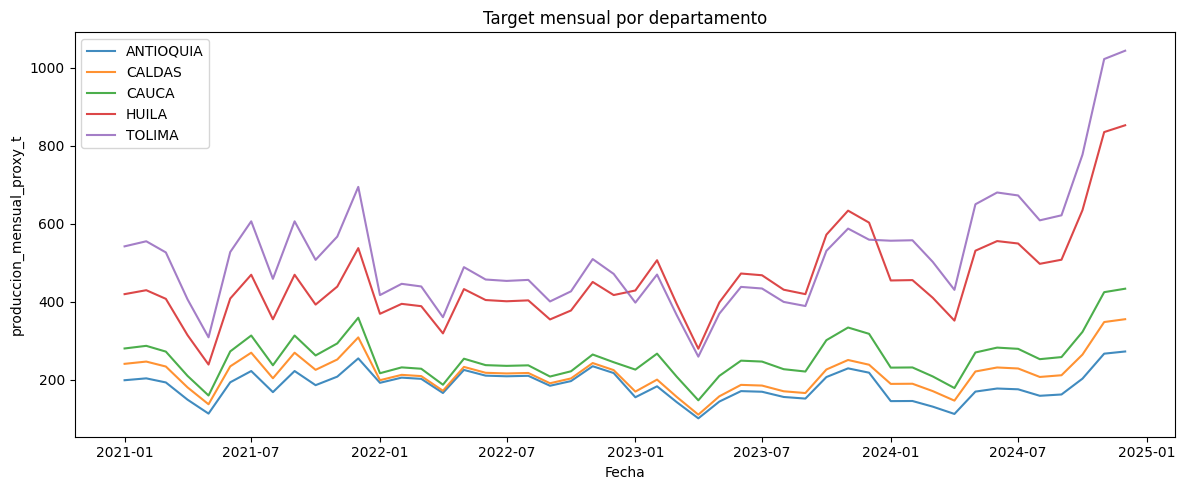

In [3]:
print("Departamentos monthly:", sorted(monthly[DEPT_COL].unique()))
print("Años monthly:", sorted(monthly[YEAR_COL].unique()))
print("Meses monthly:", sorted(monthly[MONTH_COL].unique()))

display(monthly[[TARGET_MONTHLY]].describe().T)

fig, ax = plt.subplots(figsize=(12, 5))

for dept, g in monthly.groupby(DEPT_COL):
    g = g.sort_values([YEAR_COL, MONTH_COL]).copy()
    g["fecha_mensual"] = pd.to_datetime(
        g[YEAR_COL].astype(str) + "-" + g[MONTH_COL].astype(str).str.zfill(2) + "-01"
    )
    ax.plot(g["fecha_mensual"], g[TARGET_MONTHLY], label=dept, alpha=0.85)

ax.set_title("Target mensual por departamento")
ax.set_xlabel("Fecha")
ax.set_ylabel(TARGET_MONTHLY)
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except:
    XGBOOST_AVAILABLE = False

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ])

    return preprocessor

def metrics_reg(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    den = np.where(np.abs(y_true) < 1e-9, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / den)) * 100

    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_pct": mape,
        "R2": r2,
        "Corr": corr
    }

def run_experiment(train_df, val_df, test_df, features, target, model_name, model):
    keep = [c for c in features if c in train_df.columns]

    X_train = train_df[keep].copy()
    y_train = train_df[target].copy()

    X_val = val_df[keep].copy()
    y_val = val_df[target].copy()

    X_test = test_df[keep].copy()
    y_test = test_df[target].copy()

    preprocessor = build_preprocessor(X_train)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred_val = pipe.predict(X_val)
    pred_test = pipe.predict(X_test)

    m_val = metrics_reg(y_val, pred_val)
    m_test = metrics_reg(y_test, pred_test)

    return {
        "features_n": len(keep),
        "features_used": keep,
        "model_type": model_name,
        "val_RMSE": m_val["RMSE"],
        "val_MAE": m_val["MAE"],
        "val_MAPE_pct": m_val["MAPE_pct"],
        "val_R2": m_val["R2"],
        "val_Corr": m_val["Corr"],
        "test_RMSE": m_test["RMSE"],
        "test_MAE": m_test["MAE"],
        "test_MAPE_pct": m_test["MAPE_pct"],
        "test_R2": m_test["R2"],
        "test_Corr": m_test["Corr"],
        "pipeline": pipe
    }

def keep_existing(df, cols):
    return [c for c in cols if c in df.columns]

In [5]:
BASELINE_MONTHLY = [DEPT_COL, YEAR_COL, MONTH_COL]

CLIMA_MONTHLY = [
    "PRECTOTCORR",
    "IMERG_PRECTOT",
    "lluvia_acum_4s",
    "lluvia_acum_8s",
    "T2M_mean",
    "T2M_MAX_mean",
    "T2M_MIN_mean",
    "RH2M_mean",
    "QV2M_mean",
    "GWETTOP_mean",
    "GWETROOT_mean",
    "ALLSKY_SFC_SW_DWN_mean",
    "WS2M_mean",
    "anomalia_lluvia_semana_iso_mean",
    "t2m_max_ma_4s_mean",
    "gwetroot_ma_4s_mean",
    "gwettop_ma_4s_mean",
    "dummy_exceso_lluvia_p75_any",
    "dummy_estres_hidrico_p25_any",
    "dummy_temp_max_alta_p75_any",
    "dummy_indice_climatico_bajo_p25_any",
    "dummy_indice_climatico_alto_p75_any",
]

ECON_MONTHLY = [
    "precio_interno_cop_carga_mean",
    "precio_interno_cop_carga_lag_1s_mean",
    "precio_interno_cop_carga_lag_4s_mean",
    "precio_interno_cop_carga_ma_4s_mean",
    "precio_interno_cop_carga_var_4s_mean",
    "precio_externo_exdock_cent_usd_lb_mean",
    "precio_externo_exdock_cent_usd_lb_lag_1s_mean",
    "precio_externo_exdock_cent_usd_lb_lag_4s_mean",
    "precio_externo_exdock_cent_usd_lb_ma_4s_mean",
    "precio_externo_exdock_cent_usd_lb_var_4s_mean",
    "exportaciones_mensual_miles_sacos_mean",
    "exportaciones_mensual_miles_sacos_lag_1s_mean",
    "exportaciones_mensual_miles_sacos_lag_4s_mean",
    "exportaciones_mensual_miles_sacos_ma_4s_mean",
    "exportaciones_mensual_miles_sacos_var_4s_mean",
    "trm_viernes_cop_usd_mean",
    "trm_promedio_semana_cop_usd_mean",
    "trm_viernes_cop_usd_lag_1s_mean",
    "trm_viernes_cop_usd_lag_4s_mean",
    "trm_viernes_cop_usd_ma_4s_mean",
    "trm_viernes_cop_usd_var_4s_mean",
    "dummy_trm_lag4_alta_p75_any",
    "dummy_devaluacion_4s_p75_any",
    "dummy_precio_interno_alto_p75_any",
    "dummy_precio_externo_alto_p75_any",
    "dummy_exportaciones_altas_p75_any",
]

STRUCTURAL_MONTHLY = [
    "area_cosechada_departamental_ha",
    "rendimiento_departamental_t_ha",
    "valor_cosecha_anual_millones",
]

BASELINE_MONTHLY = keep_existing(monthly, BASELINE_MONTHLY)
CLIMA_MONTHLY = keep_existing(monthly, CLIMA_MONTHLY)
ECON_MONTHLY = keep_existing(monthly, ECON_MONTHLY)
STRUCTURAL_MONTHLY = keep_existing(monthly, STRUCTURAL_MONTHLY)

print("BASELINE_MONTHLY:", BASELINE_MONTHLY)
print("CLIMA_MONTHLY:", CLIMA_MONTHLY)
print("ECON_MONTHLY:", ECON_MONTHLY)
print("STRUCTURAL_MONTHLY:", STRUCTURAL_MONTHLY)

BASELINE_MONTHLY: ['departamento', 'anio_referencia_y', 'mes_referencia_y']
CLIMA_MONTHLY: ['PRECTOTCORR', 'IMERG_PRECTOT', 'lluvia_acum_4s', 'lluvia_acum_8s', 'T2M_mean', 'T2M_MAX_mean', 'T2M_MIN_mean', 'RH2M_mean', 'QV2M_mean', 'GWETTOP_mean', 'GWETROOT_mean', 'ALLSKY_SFC_SW_DWN_mean', 'WS2M_mean', 'anomalia_lluvia_semana_iso_mean', 't2m_max_ma_4s_mean', 'gwetroot_ma_4s_mean', 'gwettop_ma_4s_mean', 'dummy_exceso_lluvia_p75_any', 'dummy_estres_hidrico_p25_any', 'dummy_temp_max_alta_p75_any', 'dummy_indice_climatico_bajo_p25_any', 'dummy_indice_climatico_alto_p75_any']
ECON_MONTHLY: ['precio_interno_cop_carga_mean', 'precio_interno_cop_carga_lag_1s_mean', 'precio_interno_cop_carga_lag_4s_mean', 'precio_interno_cop_carga_ma_4s_mean', 'precio_interno_cop_carga_var_4s_mean', 'precio_externo_exdock_cent_usd_lb_mean', 'precio_externo_exdock_cent_usd_lb_lag_1s_mean', 'precio_externo_exdock_cent_usd_lb_lag_4s_mean', 'precio_externo_exdock_cent_usd_lb_ma_4s_mean', 'precio_externo_exdock_cent_u

In [6]:
monthly_model = monthly.copy()

train_m = monthly_model[monthly_model[YEAR_COL].isin([2021, 2022])].copy()
val_m   = monthly_model[monthly_model[YEAR_COL] == 2023].copy()
test_m  = monthly_model[monthly_model[YEAR_COL] == 2024].copy()

print("train_m:", train_m.shape)
print("val_m:", val_m.shape)
print("test_m:", test_m.shape)

train_m: (120, 74)
val_m: (60, 74)
test_m: (60, 74)


In [7]:
MONTHLY_EXPERIMENTS = {
    "M0_dummy": {
        "features": BASELINE_MONTHLY,
        "model_name": "dummy",
        "model": DummyRegressor(strategy="mean")
    },
    "M1_baseline_ridge": {
        "features": BASELINE_MONTHLY,
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    },
    "M2_clima_ridge": {
        "features": BASELINE_MONTHLY + CLIMA_MONTHLY,
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    },
    "M3_clima_econ_ridge": {
        "features": BASELINE_MONTHLY + CLIMA_MONTHLY + ECON_MONTHLY,
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    },
    "M4_clima_rf": {
        "features": BASELINE_MONTHLY + CLIMA_MONTHLY,
        "model_name": "rf",
        "model": RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        )
    },
    "M5_clima_econ_rf": {
        "features": BASELINE_MONTHLY + CLIMA_MONTHLY + ECON_MONTHLY,
        "model_name": "rf",
        "model": RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        )
    },
    "M6_clima_econ_struct_rf": {
        "features": BASELINE_MONTHLY + CLIMA_MONTHLY + ECON_MONTHLY + STRUCTURAL_MONTHLY,
        "model_name": "rf",
        "model": RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        )
    }
}

if XGBOOST_AVAILABLE:
    MONTHLY_EXPERIMENTS["M7_clima_econ_xgb"] = {
        "features": BASELINE_MONTHLY + CLIMA_MONTHLY + ECON_MONTHLY,
        "model_name": "xgb",
        "model": XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42
        )
    }

list(MONTHLY_EXPERIMENTS.keys())

['M0_dummy',
 'M1_baseline_ridge',
 'M2_clima_ridge',
 'M3_clima_econ_ridge',
 'M4_clima_rf',
 'M5_clima_econ_rf',
 'M6_clima_econ_struct_rf',
 'M7_clima_econ_xgb']

In [8]:
monthly_results = []

for name, spec in MONTHLY_EXPERIMENTS.items():
    print(f"Corriendo {name} ...")
    out = run_experiment(
        train_df=train_m,
        val_df=val_m,
        test_df=test_m,
        features=spec["features"],
        target=TARGET_MONTHLY,
        model_name=spec["model_name"],
        model=spec["model"]
    )
    out["experiment"] = name
    monthly_results.append(out)

monthly_results_df = pd.DataFrame(monthly_results).drop(columns=["pipeline", "features_used"], errors="ignore")
monthly_results_df = monthly_results_df.sort_values(["val_RMSE", "test_RMSE"])

display(monthly_results_df)

Corriendo M0_dummy ...
Corriendo M1_baseline_ridge ...
Corriendo M2_clima_ridge ...
Corriendo M3_clima_econ_ridge ...
Corriendo M4_clima_rf ...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Corriendo M5_clima_econ_rf ...
Corriendo M6_clima_econ_struct_rf ...
Corriendo M7_clima_econ_xgb ...


,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr,experiment
6,54,rf,62.916842,47.368175,17.654082,0.803985,0.902436,144.715742,87.722928,19.817314,0.593179,0.883121,M6_clima_econ_struct_rf
7,51,xgb,62.966575,46.074339,16.752319,0.803675,0.923942,150.300998,94.254008,20.326027,0.561171,0.929572,M7_clima_econ_xgb
5,51,rf,66.338504,49.416095,18.316781,0.782085,0.896468,149.602184,92.428560,20.402728,0.565242,0.908368,M5_clima_econ_rf
4,25,rf,72.813176,54.258213,20.544667,0.737472,0.863496,161.853241,99.122637,21.435547,0.491121,0.840240,M4_clima_rf
1,3,ridge,78.892816,56.743334,17.702441,0.691802,0.866814,197.843496,145.573700,33.175808,0.239647,0.906704,M1_baseline_ridge
2,25,ridge,79.485377,56.139117,17.930598,0.687155,0.876057,202.651383,153.081724,36.265997,0.202242,0.903261,M2_clima_ridge
0,3,dummy,142.549263,126.065166,52.570857,-0.006202,NaN,238.107355,181.420834,50.775558,-0.101330,NaN,M0_dummy
3,51,ridge,230.321159,195.049550,81.724390,-1.626776,0.531577,315.690923,204.126154,65.817494,-0.935958,0.294977,M3_clima_econ_ridge


Mejor modelo mensual: M6_clima_econ_struct_rf
Features usadas: ['departamento', 'anio_referencia_y', 'mes_referencia_y', 'PRECTOTCORR', 'IMERG_PRECTOT', 'lluvia_acum_4s', 'lluvia_acum_8s', 'T2M_mean', 'T2M_MAX_mean', 'T2M_MIN_mean', 'RH2M_mean', 'QV2M_mean', 'GWETTOP_mean', 'GWETROOT_mean', 'ALLSKY_SFC_SW_DWN_mean', 'WS2M_mean', 'anomalia_lluvia_semana_iso_mean', 't2m_max_ma_4s_mean', 'gwetroot_ma_4s_mean', 'gwettop_ma_4s_mean', 'dummy_exceso_lluvia_p75_any', 'dummy_estres_hidrico_p25_any', 'dummy_temp_max_alta_p75_any', 'dummy_indice_climatico_bajo_p25_any', 'dummy_indice_climatico_alto_p75_any', 'precio_interno_cop_carga_mean', 'precio_interno_cop_carga_lag_1s_mean', 'precio_interno_cop_carga_lag_4s_mean', 'precio_interno_cop_carga_ma_4s_mean', 'precio_interno_cop_carga_var_4s_mean', 'precio_externo_exdock_cent_usd_lb_mean', 'precio_externo_exdock_cent_usd_lb_lag_1s_mean', 'precio_externo_exdock_cent_usd_lb_lag_4s_mean', 'precio_externo_exdock_cent_usd_lb_ma_4s_mean', 'precio_externo

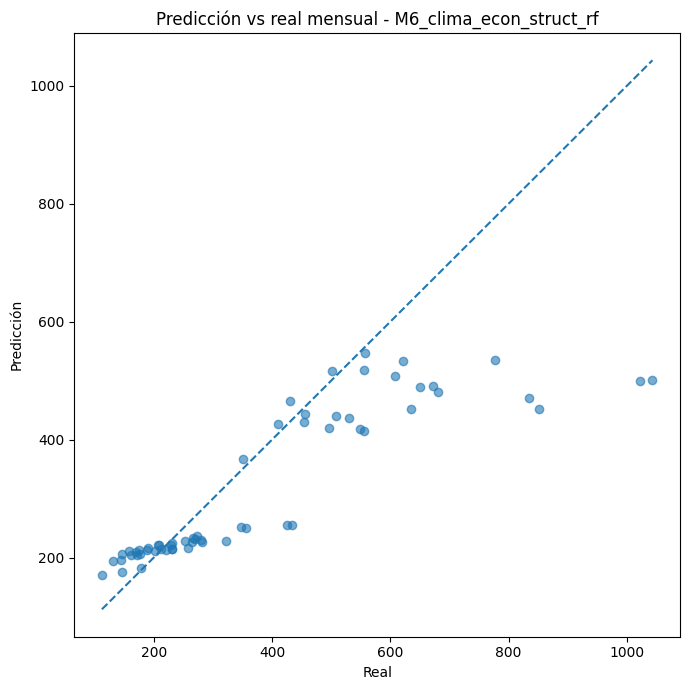

In [9]:
best_monthly_name = monthly_results_df.iloc[0]["experiment"]
best_monthly_result = [r for r in monthly_results if r["experiment"] == best_monthly_name][0]
best_monthly_pipe = best_monthly_result["pipeline"]
best_monthly_features = best_monthly_result["features_used"]

print("Mejor modelo mensual:", best_monthly_name)
print("Features usadas:", best_monthly_features)

X_test_m = test_m[best_monthly_features].copy()
y_test_m = test_m[TARGET_MONTHLY].copy()
pred_test_m = best_monthly_pipe.predict(X_test_m)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test_m, pred_test_m, alpha=0.6)
lims = [min(y_test_m.min(), pred_test_m.min()), max(y_test_m.max(), pred_test_m.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_title(f"Predicción vs real mensual - {best_monthly_name}")
ax.set_xlabel("Real")
ax.set_ylabel("Predicción")
plt.tight_layout()
plt.show()

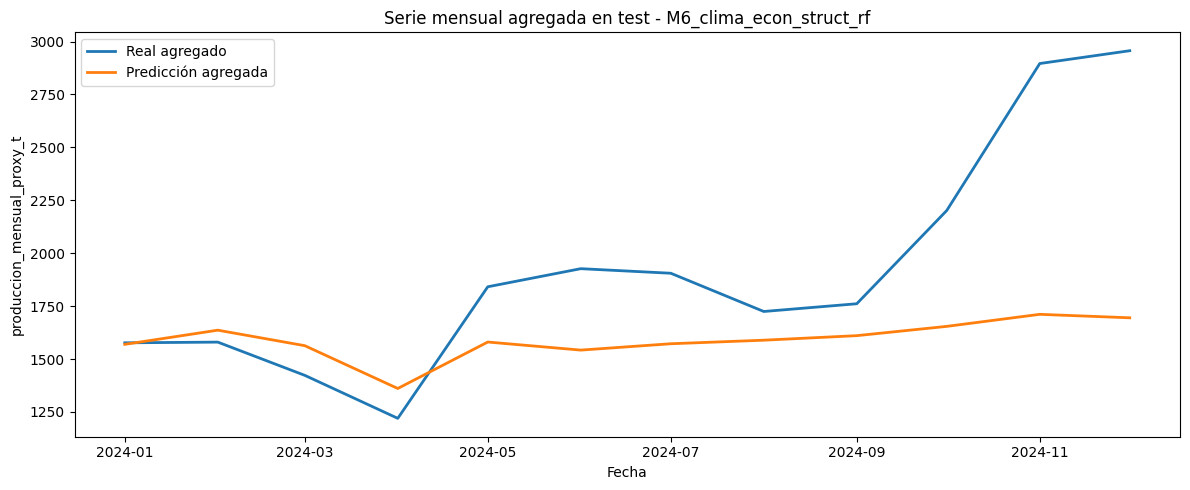

In [10]:
test_plot_m = test_m[[DEPT_COL, YEAR_COL, MONTH_COL, TARGET_MONTHLY]].copy()
test_plot_m["pred"] = pred_test_m
test_plot_m["fecha_mensual"] = pd.to_datetime(
    test_plot_m[YEAR_COL].astype(str) + "-" + test_plot_m[MONTH_COL].astype(str).str.zfill(2) + "-01"
)

series_m = test_plot_m.groupby("fecha_mensual")[[TARGET_MONTHLY, "pred"]].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(series_m["fecha_mensual"], series_m[TARGET_MONTHLY], label="Real agregado", linewidth=2)
ax.plot(series_m["fecha_mensual"], series_m["pred"], label="Predicción agregada", linewidth=2)
ax.set_title(f"Serie mensual agregada en test - {best_monthly_name}")
ax.set_xlabel("Fecha")
ax.set_ylabel(TARGET_MONTHLY)
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# =========================
# Comparación M5 vs M6
# =========================

compare_m5_m6 = monthly_results_df[
    monthly_results_df["experiment"].isin(["M5_clima_econ_rf", "M6_clima_econ_struct_rf"])
].copy()

display(compare_m5_m6)

,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr,experiment
6,54,rf,62.916842,47.368175,17.654082,0.803985,0.902436,144.715742,87.722928,19.817314,0.593179,0.883121,M6_clima_econ_struct_rf
5,51,rf,66.338504,49.416095,18.316781,0.782085,0.896468,149.602184,92.428560,20.402728,0.565242,0.908368,M5_clima_econ_rf


,feature,importance
50,num__area_cosechada_departamental_ha,0.804128
34,num__exportaciones_mensual_miles_sacos_mean,0.031993
38,num__exportaciones_mensual_miles_sacos_var_4s_...,0.019217
9,num__RH2M_mean,0.017784
6,num__T2M_mean,0.016669
51,num__rendimiento_departamental_t_ha,0.016203
7,num__T2M_MAX_mean,0.008551
14,num__WS2M_mean,0.007117
11,num__GWETTOP_mean,0.006953
8,num__T2M_MIN_mean,0.006773


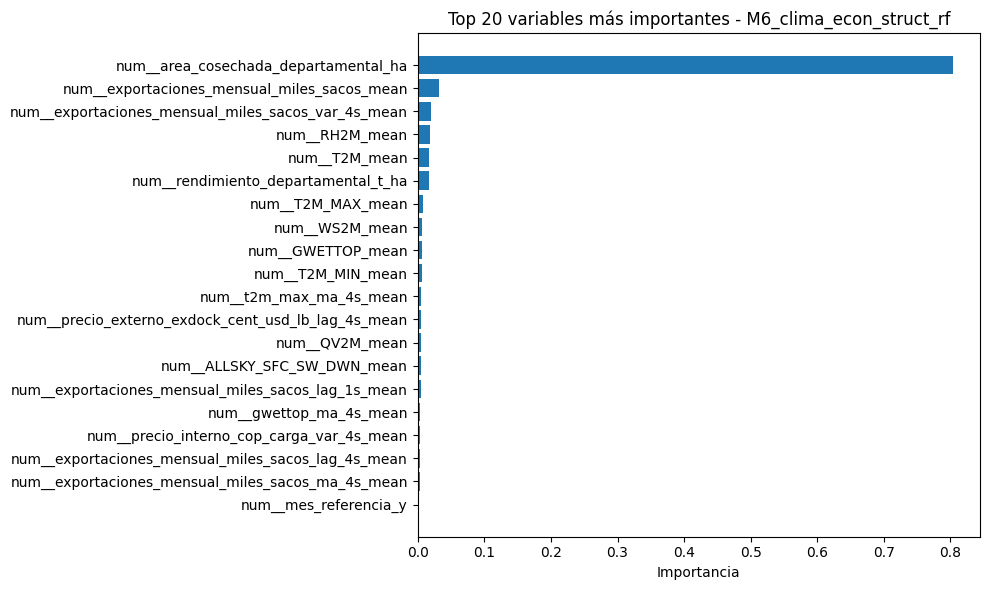

In [12]:
# =========================
# Importancia de variables - mejor modelo mensual
# =========================

model_step_m = best_monthly_pipe.named_steps["model"]
prep_step_m = best_monthly_pipe.named_steps["prep"]

feature_names_m = prep_step_m.get_feature_names_out()
importances_m = model_step_m.feature_importances_

feat_imp_m = pd.DataFrame({
    "feature": feature_names_m,
    "importance": importances_m
}).sort_values("importance", ascending=False)

display(feat_imp_m.head(20))

plt.figure(figsize=(10, 6))
topn = 20
plot_df_m = feat_imp_m.head(topn).sort_values("importance")
plt.barh(plot_df_m["feature"], plot_df_m["importance"])
plt.title(f"Top {topn} variables más importantes - {best_monthly_name}")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [13]:
# =========================
# Métricas por departamento - mejor modelo mensual
# =========================

test_eval_m = test_m[[DEPT_COL, YEAR_COL, MONTH_COL, TARGET_MONTHLY]].copy()
test_eval_m["pred"] = pred_test_m

def metrics_reg_simple(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    den = np.where(np.abs(y_true) < 1e-9, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / den)) * 100
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return pd.Series({
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_pct": mape,
        "R2": r2,
        "Corr": corr
    })

dept_metrics_m = (
    test_eval_m.groupby(DEPT_COL)
    .apply(lambda g: metrics_reg_simple(g[TARGET_MONTHLY], g["pred"]))
    .reset_index()
    .sort_values("RMSE")
)

display(dept_metrics_m)

/tmp/ipykernel_2819/1158411062.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metrics_reg_simple(g[TARGET_MONTHLY], g["pred"]))


,departamento,RMSE,MAE,MAPE_pct,R2,Corr
0,ANTIOQUIA,44.966800,42.452991,27.096005,0.092360,0.918427
1,CALDAS,46.404848,33.742360,13.448266,0.431219,0.923398
2,CAUCA,81.072458,57.528964,17.136893,-0.166490,0.882052
3,HUILA,178.607771,126.961045,19.258739,-0.464146,0.721203
4,TOLIMA,249.127131,177.929280,22.146668,-0.900841,-0.009906


,family,importance
2,estructural,0.820590
0,climatica,0.094971
1,economica,0.080937
3,temporal,0.002683
4,territorial,0.000819


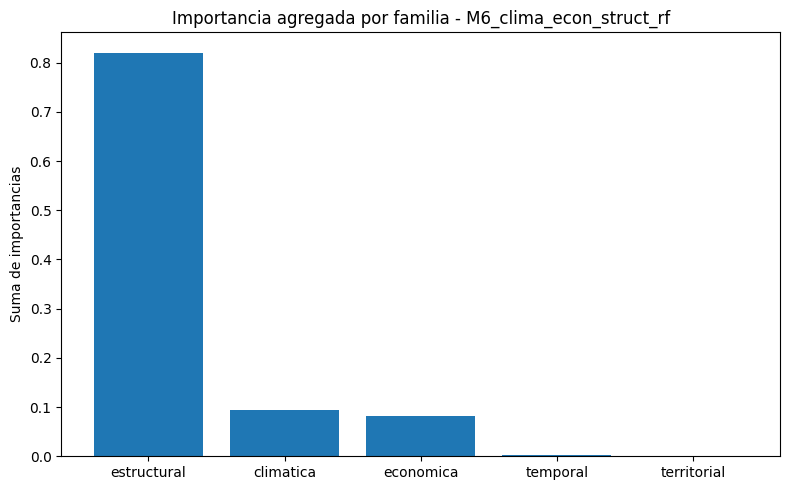

In [14]:
# =========================
# Importancia agregada por familia - monthly
# =========================

def classify_feature_family_monthly(feature_name):
    f = feature_name.lower()

    if "departamento" in f:
        return "territorial"

    if any(x in f for x in ["anio_referencia_y", "mes_referencia_y", "year", "month", "quarter"]):
        return "temporal"

    if any(x in f for x in [
        "precio_", "trm", "exportaciones", "devaluacion"
    ]):
        return "economica"

    if any(x in f for x in [
        "area_cosechada", "rendimiento_departamental", "valor_cosecha_anual"
    ]):
        return "estructural"

    if any(x in f for x in [
        "prectotcorr", "imerg_prectot", "t2m", "rh2m", "qv2m", "gwettop", "gwetroot",
        "allsky", "ws2m", "lluvia", "humedad", "indice_climatico",
        "estres_hidrico", "temp_max", "exceso_lluvia"
    ]):
        return "climatica"

    return "otra"

feat_imp_m_family = feat_imp_m.copy()
feat_imp_m_family["family"] = feat_imp_m_family["feature"].apply(classify_feature_family_monthly)

family_summary_m = (
    feat_imp_m_family.groupby("family", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(family_summary_m)

plt.figure(figsize=(8, 5))
plt.bar(family_summary_m["family"], family_summary_m["importance"])
plt.title(f"Importancia agregada por familia - {best_monthly_name}")
plt.ylabel("Suma de importancias")
plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# ANNUAL - Setup
# ==========================================

TARGET_ANNUAL_1 = "rendimiento_departamental_t_ha"
TARGET_ANNUAL_2 = "produccion_anual_departamental_t"

print("Shape annual:", annual.shape)
print("Departamentos:", sorted(annual["departamento"].unique()))
print("Años:", sorted(annual["anio_referencia_y"].unique()))

display(annual[[TARGET_ANNUAL_1, TARGET_ANNUAL_2]].describe().T)
display(annual.head())

Shape annual: (20, 73)
Departamentos: ['ANTIOQUIA', 'CALDAS', 'CAUCA', 'HUILA', 'TOLIMA']
Años: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,count,mean,std,min,25%,50%,75%,max
rendimiento_departamental_t_ha,20.0,1.1175,0.221950,0.67,1.015,1.120,1.2225,1.47
produccion_anual_departamental_t,20.0,3919.4300,1786.153272,2029.31,2518.430,3108.155,5231.0275,8120.99


,departamento,anio_referencia_y,produccion_anual_desde_semana_t,produccion_mensual_proxy_t,produccion_anual_departamental_t,area_cosechada_departamental_ha,rendimiento_departamental_t_ha,peso_mensual_prod_nacional,produccion_nacional_mensual_oficial_miles_sacos,valor_cosecha_anual_millones,...,exportaciones_mensual_miles_sacos_var_4s_mean,trm_viernes_cop_usd_mean,trm_promedio_semana_cop_usd_mean,trm_viernes_cop_usd_lag_1s_mean,trm_viernes_cop_usd_lag_4s_mean,trm_viernes_cop_usd_ma_4s_mean,trm_viernes_cop_usd_var_4s_mean,nivel,dias_productivos_periodo_2021_2024,diff_target_anual
0,ANTIOQUIA,2021,2313.87,198.878387,2313.87,1752.93,1.32,0.085951,1081,1.076853e+07,...,0.101066,3749.625192,3746.956154,3739.074038,3725.513061,3745.000200,0.011042,PANEL_DEPARTAMENTAL,7,-6.843999
1,ANTIOQUIA,2022,2454.68,192.235590,2454.68,1789.27,1.37,0.078314,868,1.450223e+07,...,-0.000598,4264.701731,4258.470769,4248.758654,4201.031731,4241.665577,0.015788,PANEL_DEPARTAMENTAL,7,-7.395022
2,ANTIOQUIA,2023,2029.31,155.225489,2029.31,1703.30,1.19,0.076492,868,1.114309e+07,...,0.010405,4314.476731,4323.717115,4333.479615,4381.418269,4340.771923,-0.014385,PANEL_DEPARTAMENTAL,7,-5.007274
3,ANTIOQUIA,2024,2121.27,145.333520,2121.27,1440.21,1.47,0.068513,959,1.606189e+07,...,0.021270,4071.300769,4069.508846,4060.148269,4036.268269,4056.672115,0.008866,PANEL_DEPARTAMENTAL,7,-17.581700
4,CALDAS,2021,2802.47,240.873823,2802.47,2571.07,1.09,0.085951,1081,1.076853e+07,...,0.101066,3749.625192,3746.956154,3739.074038,3725.513061,3745.000200,0.011042,PANEL_DEPARTAMENTAL,7,-10.478610


In [16]:
# ==========================================
# ANNUAL - Variables
# ==========================================

DEPT_COL = "departamento"
YEAR_COL = "anio_referencia_y"

def keep_existing(df, cols):
    return [c for c in cols if c in df.columns]

BASELINE_ANNUAL = [DEPT_COL, YEAR_COL]

CLIMA_ANNUAL = [
    "PRECTOTCORR",
    "IMERG_PRECTOT",
    "lluvia_acum_4s",
    "lluvia_acum_8s",
    "T2M_mean",
    "T2M_MAX_mean",
    "T2M_MIN_mean",
    "RH2M_mean",
    "QV2M_mean",
    "GWETTOP_mean",
    "GWETROOT_mean",
    "ALLSKY_SFC_SW_DWN_mean",
    "WS2M_mean",
    "anomalia_lluvia_semana_iso_mean",
    "t2m_max_ma_4s_mean",
    "gwetroot_ma_4s_mean",
    "gwettop_ma_4s_mean",
    "dummy_exceso_lluvia_p75_mean",
    "dummy_estres_hidrico_p25_mean",
    "dummy_temp_max_alta_p75_mean",
    "dummy_indice_climatico_bajo_p25_mean",
    "dummy_indice_climatico_alto_p75_mean",
]

ECON_ANNUAL = [
    "precio_interno_cop_carga_mean",
    "precio_externo_exdock_cent_usd_lb_mean",
    "exportaciones_mensual_miles_sacos_mean",
    "trm_promedio_semana_cop_usd_mean",
]

BASELINE_ANNUAL = keep_existing(annual, BASELINE_ANNUAL)
CLIMA_ANNUAL = keep_existing(annual, CLIMA_ANNUAL)
ECON_ANNUAL = keep_existing(annual, ECON_ANNUAL)

print("BASELINE_ANNUAL:", BASELINE_ANNUAL)
print("CLIMA_ANNUAL:", CLIMA_ANNUAL)
print("ECON_ANNUAL:", ECON_ANNUAL)

BASELINE_ANNUAL: ['departamento', 'anio_referencia_y']
CLIMA_ANNUAL: ['PRECTOTCORR', 'IMERG_PRECTOT', 'lluvia_acum_4s', 'lluvia_acum_8s', 'T2M_mean', 'T2M_MAX_mean', 'T2M_MIN_mean', 'RH2M_mean', 'QV2M_mean', 'GWETTOP_mean', 'GWETROOT_mean', 'ALLSKY_SFC_SW_DWN_mean', 'WS2M_mean', 'anomalia_lluvia_semana_iso_mean', 't2m_max_ma_4s_mean', 'gwetroot_ma_4s_mean', 'gwettop_ma_4s_mean', 'dummy_exceso_lluvia_p75_mean', 'dummy_estres_hidrico_p25_mean', 'dummy_temp_max_alta_p75_mean', 'dummy_indice_climatico_bajo_p25_mean', 'dummy_indice_climatico_alto_p75_mean']
ECON_ANNUAL: ['precio_interno_cop_carga_mean', 'precio_externo_exdock_cent_usd_lb_mean', 'exportaciones_mensual_miles_sacos_mean', 'trm_promedio_semana_cop_usd_mean']


In [17]:
# ==========================================
# ANNUAL - Split temporal
# ==========================================

train_a = annual[annual[YEAR_COL].isin([2021, 2022])].copy()
val_a   = annual[annual[YEAR_COL] == 2023].copy()
test_a  = annual[annual[YEAR_COL] == 2024].copy()

print("train_a:", train_a.shape)
print("val_a:", val_a.shape)
print("test_a:", test_a.shape)

train_a: (10, 73)
val_a: (5, 73)
test_a: (5, 73)


In [18]:
# ==========================================
# ANNUAL - Funciones auxiliares
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import RidgeCV

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ])

def metrics_reg(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    den = np.where(np.abs(y_true) < 1e-9, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / den)) * 100
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {"RMSE": rmse, "MAE": mae, "MAPE_pct": mape, "R2": r2, "Corr": corr}

def run_experiment(train_df, val_df, test_df, features, target, model_name, model):
    keep = [c for c in features if c in train_df.columns]

    X_train = train_df[keep].copy()
    y_train = train_df[target].copy()

    X_val = val_df[keep].copy()
    y_val = val_df[target].copy()

    X_test = test_df[keep].copy()
    y_test = test_df[target].copy()

    preprocessor = build_preprocessor(X_train)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred_val = pipe.predict(X_val)
    pred_test = pipe.predict(X_test)

    m_val = metrics_reg(y_val, pred_val)
    m_test = metrics_reg(y_test, pred_test)

    return {
        "features_n": len(keep),
        "features_used": keep,
        "model_type": model_name,
        "val_RMSE": m_val["RMSE"],
        "val_MAE": m_val["MAE"],
        "val_MAPE_pct": m_val["MAPE_pct"],
        "val_R2": m_val["R2"],
        "val_Corr": m_val["Corr"],
        "test_RMSE": m_test["RMSE"],
        "test_MAE": m_test["MAE"],
        "test_MAPE_pct": m_test["MAPE_pct"],
        "test_R2": m_test["R2"],
        "test_Corr": m_test["Corr"],
        "pipeline": pipe
    }

In [19]:
# ==========================================
# ANNUAL - Experimentos para rendimiento
# ==========================================

ANNUAL_EXPERIMENTS = {
    "A0_dummy": {
        "features": BASELINE_ANNUAL,
        "model_name": "dummy",
        "model": DummyRegressor(strategy="mean")
    },
    "A1_baseline_ridge": {
        "features": BASELINE_ANNUAL,
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    },
    "A2_clima_ridge": {
        "features": BASELINE_ANNUAL + CLIMA_ANNUAL,
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    },
    "A3_clima_econ_ridge": {
        "features": BASELINE_ANNUAL + CLIMA_ANNUAL + ECON_ANNUAL,
        "model_name": "ridge",
        "model": RidgeCV(alphas=np.logspace(-3, 3, 20))
    }
}

annual_results_rend = []

for name, spec in ANNUAL_EXPERIMENTS.items():
    print(f"Corriendo {name} ...")
    out = run_experiment(
        train_df=train_a,
        val_df=val_a,
        test_df=test_a,
        features=spec["features"],
        target=TARGET_ANNUAL_1,
        model_name=spec["model_name"],
        model=spec["model"]
    )
    out["experiment"] = name
    annual_results_rend.append(out)

annual_results_rend_df = pd.DataFrame(annual_results_rend).drop(columns=["pipeline", "features_used"], errors="ignore")
annual_results_rend_df = annual_results_rend_df.sort_values(["val_RMSE", "test_RMSE"])

display(annual_results_rend_df)

Corriendo A0_dummy ...
Corriendo A1_baseline_ridge ...
Corriendo A2_clima_ridge ...
Corriendo A3_clima_econ_ridge ...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr,experiment
1,2,ridge,0.120078,0.089131,8.042474,0.625918,0.840867,0.426870,0.412754,31.613625,-6.342764,0.788247,A1_baseline_ridge
2,24,ridge,0.152888,0.145005,15.662424,0.393554,0.738113,0.268896,0.235498,17.682022,-1.913656,0.670529,A2_clima_ridge
3,28,ridge,0.157939,0.150905,16.331060,0.352828,0.739879,0.252663,0.216858,16.249443,-1.572479,0.671771,A3_clima_econ_ridge
0,2,dummy,0.200360,0.163200,19.429666,-0.041511,NaN,0.298885,0.254000,18.022514,-2.599774,NaN,A0_dummy


Mejor modelo annual (rendimiento): A1_baseline_ridge
Features usadas: ['departamento', 'anio_referencia_y']


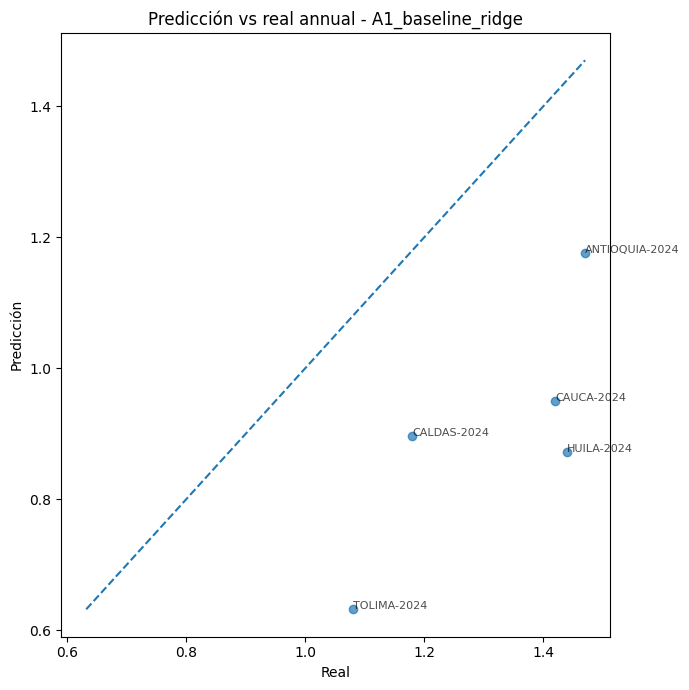

In [20]:
# ==========================================
# ANNUAL - Mejor modelo para rendimiento
# ==========================================

best_annual_rend_name = annual_results_rend_df.iloc[0]["experiment"]
best_annual_rend_result = [r for r in annual_results_rend if r["experiment"] == best_annual_rend_name][0]
best_annual_rend_pipe = best_annual_rend_result["pipeline"]
best_annual_rend_features = best_annual_rend_result["features_used"]

print("Mejor modelo annual (rendimiento):", best_annual_rend_name)
print("Features usadas:", best_annual_rend_features)

X_test_a = test_a[best_annual_rend_features].copy()
y_test_a = test_a[TARGET_ANNUAL_1].copy()
pred_test_a = best_annual_rend_pipe.predict(X_test_a)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test_a, pred_test_a, alpha=0.7)

lims = [min(y_test_a.min(), pred_test_a.min()), max(y_test_a.max(), pred_test_a.max())]
ax.plot(lims, lims, linestyle="--")

for i in range(len(test_a)):
    ax.annotate(
        f"{test_a.iloc[i][DEPT_COL]}-{int(test_a.iloc[i][YEAR_COL])}",
        (y_test_a.iloc[i], pred_test_a[i]),
        fontsize=8,
        alpha=0.7
    )

ax.set_title(f"Predicción vs real annual - {best_annual_rend_name}")
ax.set_xlabel("Real")
ax.set_ylabel("Predicción")
plt.tight_layout()
plt.show()

,feature,coef,abs_coef
5,cat__departamento_TOLIMA,-0.273277,0.273277
1,cat__departamento_ANTIOQUIA,0.270390,0.270390
3,cat__departamento_CAUCA,0.044263,0.044263
4,cat__departamento_HUILA,-0.032716,0.032716
0,num__anio_referencia_y,-0.031751,0.031751
2,cat__departamento_CALDAS,-0.008660,0.008660


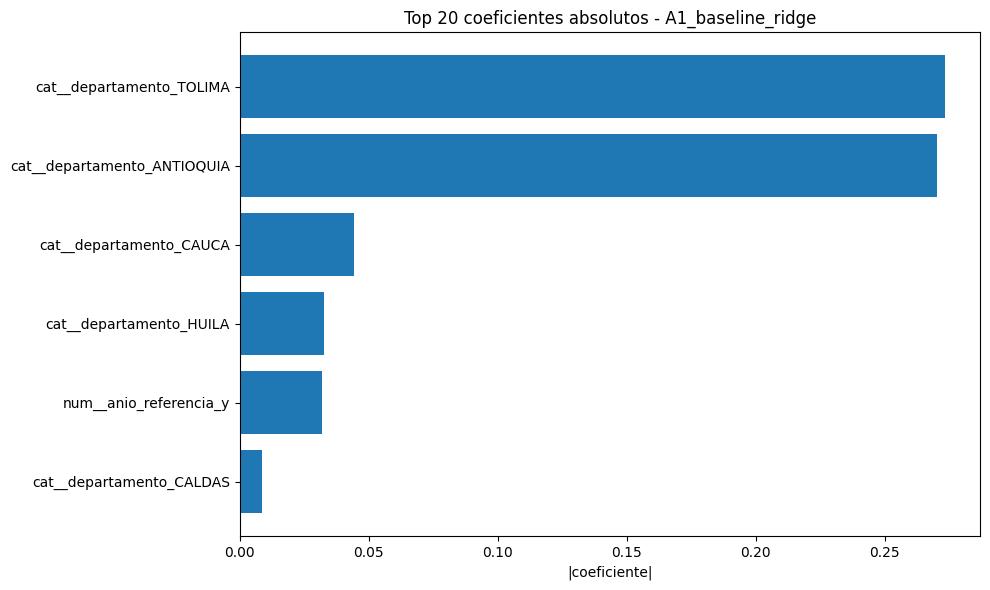

In [21]:
# ==========================================
# ANNUAL - Coeficientes del mejor modelo
# ==========================================

model_step_a = best_annual_rend_pipe.named_steps["model"]
prep_step_a = best_annual_rend_pipe.named_steps["prep"]

feature_names_a = prep_step_a.get_feature_names_out()
coefs_a = model_step_a.coef_

coef_df_a = pd.DataFrame({
    "feature": feature_names_a,
    "coef": coefs_a,
    "abs_coef": np.abs(coefs_a)
}).sort_values("abs_coef", ascending=False)

display(coef_df_a.head(20))

plt.figure(figsize=(10, 6))
plot_df_a = coef_df_a.head(20).sort_values("abs_coef")
plt.barh(plot_df_a["feature"], plot_df_a["abs_coef"])
plt.title(f"Top 20 coeficientes absolutos - {best_annual_rend_name}")
plt.xlabel("|coeficiente|")
plt.tight_layout()
plt.show()

In [22]:
# ==========================================
# ANNUAL - Experimentos para producción
# ==========================================

annual_results_prod = []

for name, spec in ANNUAL_EXPERIMENTS.items():
    print(f"Corriendo {name} ...")
    out = run_experiment(
        train_df=train_a,
        val_df=val_a,
        test_df=test_a,
        features=spec["features"],
        target=TARGET_ANNUAL_2,
        model_name=spec["model_name"],
        model=spec["model"]
    )
    out["experiment"] = name
    annual_results_prod.append(out)

annual_results_prod_df = pd.DataFrame(annual_results_prod).drop(columns=["pipeline", "features_used"], errors="ignore")
annual_results_prod_df = annual_results_prod_df.sort_values(["val_RMSE", "test_RMSE"])

display(annual_results_prod_df)

Corriendo A0_dummy ...
Corriendo A1_baseline_ridge ...
Corriendo A2_clima_ridge ...
Corriendo A3_clima_econ_ridge ...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr,experiment
1,2,ridge,643.781529,412.389795,10.040663,0.817796,0.943882,2030.094752,1744.088304,35.868985,0.251985,0.998905,A1_baseline_ridge
3,28,ridge,1388.694195,1213.422224,36.270118,0.152199,0.898327,2992.643019,2633.441604,57.625414,-0.625502,0.818509,A3_clima_econ_ridge
0,2,dummy,1514.169989,1467.632600,48.079300,-0.007930,NaN,2502.155224,2046.198600,43.934109,-0.136335,NaN,A0_dummy
2,24,ridge,1670.952811,1533.484610,46.868226,-0.227466,0.901447,3495.362701,3198.076290,73.548390,-1.217493,0.823629,A2_clima_ridge


In [23]:
# ==========================================
# ANNUAL - Comparación final
# ==========================================

print("Resultados annual - rendimiento")
display(annual_results_rend_df)

print("Resultados annual - producción")
display(annual_results_prod_df)

Resultados annual - rendimiento


,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr,experiment
1,2,ridge,0.120078,0.089131,8.042474,0.625918,0.840867,0.426870,0.412754,31.613625,-6.342764,0.788247,A1_baseline_ridge
2,24,ridge,0.152888,0.145005,15.662424,0.393554,0.738113,0.268896,0.235498,17.682022,-1.913656,0.670529,A2_clima_ridge
3,28,ridge,0.157939,0.150905,16.331060,0.352828,0.739879,0.252663,0.216858,16.249443,-1.572479,0.671771,A3_clima_econ_ridge
0,2,dummy,0.200360,0.163200,19.429666,-0.041511,NaN,0.298885,0.254000,18.022514,-2.599774,NaN,A0_dummy


Resultados annual - producción


,features_n,model_type,val_RMSE,val_MAE,val_MAPE_pct,val_R2,val_Corr,test_RMSE,test_MAE,test_MAPE_pct,test_R2,test_Corr,experiment
1,2,ridge,643.781529,412.389795,10.040663,0.817796,0.943882,2030.094752,1744.088304,35.868985,0.251985,0.998905,A1_baseline_ridge
3,28,ridge,1388.694195,1213.422224,36.270118,0.152199,0.898327,2992.643019,2633.441604,57.625414,-0.625502,0.818509,A3_clima_econ_ridge
0,2,dummy,1514.169989,1467.632600,48.079300,-0.007930,NaN,2502.155224,2046.198600,43.934109,-0.136335,NaN,A0_dummy
2,24,ridge,1670.952811,1533.484610,46.868226,-0.227466,0.901447,3495.362701,3198.076290,73.548390,-1.217493,0.823629,A2_clima_ridge


## 14. Exportar resultados

In [ ]:
results_df.to_csv("/content/resultados_modelos_panel.csv", index=False)
print("Guardado: /content/resultados_modelos_panel.csv")

best_features_df = pd.DataFrame({"feature": best_features})
best_features_df.to_csv("/content/features_mejor_modelo_panel.csv", index=False)
print("Guardado: /content/features_mejor_modelo_panel.csv")

## 15. Guía de lectura de resultados

### Qué sí podemos afirmar
- qué grupo de variables mejora más el ajuste del target semanal proxy;
- qué modelo es más estable en validación y test;
- si las variables climáticas agregan valor frente al baseline temporal;
- qué tan útil es la base panel frente a la proxy nacional.

### Qué no debemos afirmar de más
- que el target semanal sea producción observada;
- que exista causalidad estricta clima-rendimiento a escala semanal;
- que el mejor modelo implique una validación definitiva del seguro.

### Cómo reportar limitaciones
- la Y semanal es una proxy operacional no observada;
- la variación semanal se construye con una regla temporal no climática;
- el ejercicio semanal se interpreta como simulación, sensibilidad y monitoreo operacional;
- la validación más fuerte del vínculo clima-producción debe buscarse en una frecuencia anual o municipio-año si se dispone de esa base.